<a href="https://colab.research.google.com/github/MonaliM5/cardio_risk_prediction/blob/main/notebooks/Cardiovascular_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Cardiovascular Risk Prediction



##### **Project Type -**     Classification
##### **Contribution -**     Individual
##### **Student Name -**     Monali Vijay Mhaske

# **Project Summary -**

* Cardiovascular diseases are among the leading causes of death worldwide, making early risk detection a crucial public health priority.

* This project aims to develop a data-driven, machine-learning-based classification model that predicts whether an individual is at risk of cardiovascular disease using routinely collected clinical and demographic information.

* The study will begin with detailed Exploratory Data Analysis (EDA) to identify patterns and correlations between health indicators such as age, blood pressure, cholesterol, glucose levels, and lifestyle factors.

* Subsequently, relevant features will be engineered and multiple classification algorithms—including Logistic Regression, Random Forest, and XGBoost—will be applied to build predictive models.

* The performance of these models will be evaluated using metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC, followed by cross-validation and hyperparameter tuning to improve robustness.

* The final deliverable will be an explainable and deployment-ready notebook that highlights the most influential factors contributing to cardiovascular risk, thereby supporting early intervention and better clinical decision-making.


# **GitHub Link -**

https://github.com/MonaliM5/cardio_risk_prediction/tree/main

# **Problem Statement**


* Cardiovascular diseases (CVDs) continue to be one of the most significant causes of mortality globally, often resulting from undetected or poorly managed risk factors such as hypertension, obesity, high cholesterol, and unhealthy lifestyle habits.

* Early detection of individuals who are at high risk can play a vital role in preventing severe cardiac events and reducing healthcare costs.

* The challenge addressed in this project is to build a predictive model that can accurately classify whether a person is at risk of developing cardiovascular disease based on easily measurable clinical and demographic features.

* The dataset includes attributes such as age, gender, blood pressure, cholesterol, glucose levels, smoking and alcohol habits, physical activity, and body mass index (BMI).

* By leveraging supervised machine learning algorithms, the goal is to create a robust, interpretable, and deployment-ready model that assists healthcare practitioners and organizations in identifying high-risk patients early.

* Such a model can help design personalized prevention programs, prioritize medical screenings, and ultimately contribute to improving population health outcomes.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [106]:
# Import Libraries

# importing core libraries for data manipulation and computation
import numpy as np
import pandas as pd

# importing libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# importing machine learning algorithms and utilities
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# importing evaluatoin metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# importing additional tools
import warnings
warnings.filterwarnings('ignore')  # ignoring unnecessary warnings for clean output

# setting global plot aesthetics for consistency
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (8, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Dataset Loading

In [107]:
# Load Dataset
# 1️⃣ Removing any previous half-cloned folders
!rm -rf cardio-risk-prediction

# 2️⃣ Clonning the repository freshly
!git clone https://github.com/MonaliM5/cardio_risk_prediction.git

# 3️⃣ Moving into your project directory
%cd cardio_risk_prediction

# 4️⃣ Verifying that the dataset exists
!ls data/raw

Cloning into 'cardio_risk_prediction'...
remote: Enumerating objects: 444, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 444 (delta 59), reused 18 (delta 12), pack-reused 331 (from 2)
Receiving objects: 100% (444/444), 15.75 MiB | 23.78 MiB/s, done.
Resolving deltas: 100% (202/202), done.
/content/cardio_risk_prediction/cardio_risk_prediction
data_cardiovascular_risk.csv


In [108]:
# Loading the dataset
df = pd.read_csv("data/raw/data_cardiovascular_risk.csv")
print("✅ Dataset loaded successfully!")


✅ Dataset loaded successfully!


### Dataset First View

In [109]:
# Dataset First Look
# displaying the first few records to understand the data structure
# Sales Dataset First Look
print("Dataset First View ")
df.head()

Dataset First View 


,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


### Dataset Rows & Columns count

In [110]:
# Dataset Rows & Columns count
print(f"Dataset -\nRows Count : {df.shape[0]}  \tColumns Count : {df.shape[1]}")

Dataset -
Rows Count : 3390  	Columns Count : 17


### Dataset Information

In [111]:
# Dataset Info
print("Data Information:")
df.info()

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   object 
 4   is_smoking       3390 non-null   object 
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
d

#### Duplicate Values

In [112]:
# Dataset Duplicate Value Count
# Checking the number of duplicate rows in the dataset
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows in the dataset: {duplicate_count}")

Number of duplicate rows in the dataset: 0


#### Missing Values/Null Values

In [113]:
# Missing Values/Null Values Count
# checking missing values in each column

print("Missing values count per column:")
df.isnull().sum()

Missing values count per column:


,0
id,0
age,0
education,87
sex,0
is_smoking,0
cigsPerDay,22
BPMeds,44
prevalentStroke,0
prevalentHyp,0
diabetes,0


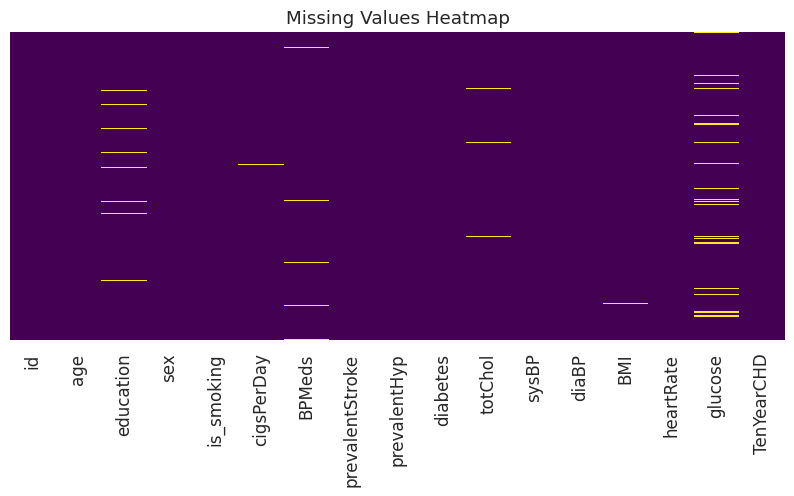

In [114]:
# Visualizing the missing values
# visualizing missing values using heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

* From the initial data exploration and quality checks, several important insights about the dataset were observed.

* The dataset represents real-world clinical and demographic information of individuals, where each row corresponds to a patient record and each column captures a specific health, lifestyle, or medical attribute.

* It includes a balanced mix of demographic factors (age, sex, education), lifestyle indicators (smoking status, cigarette consumption, physical activity), and clinical measurements (blood pressure, cholesterol, glucose, BMI, heart rate).

* The target variable `TenYearCHD` indicates whether an individual is at risk of developing coronary heart disease within the next ten years, making this a supervised binary classification problem.

* Key observations from the dataset include:

  - The data contains both continuous and categorical variables, requiring appropriate preprocessing techniques before modeling.

  - Several medically relevant features such as glucose, cholesterol, BMI, and blood pressure are present, which are known risk factors for cardiovascular disease.

  - Missing values are present in some biochemical and lifestyle-related features, reflecting realistic challenges commonly encountered in healthcare datasets.

  - No duplicate records were found, indicating good data collection quality.

* Overall, the dataset is rich, clinically meaningful, and suitable for building a predictive machine learning model after proper data cleaning and feature engineering.

* The presence of real-world imperfections such as missing values enhances the practical relevance of this project.

## ***2. Understanding Your Variables***

In [115]:
# Dataset Columns
# Printing list of columns in Sales Dataset
print("Columns in Dataset:\n")
print(df.columns.tolist())

Columns in Dataset:

['id', 'age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [116]:
# Dataset Describe
# Describing the Sales Dataset
print("Data Description : \n")
display(df.describe())

Data Description : 



,id,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3390.000000,3390.000000,3303.000000,3368.000000,3346.000000,3390.000000,3390.000000,3390.000000,3352.000000,3390.00000,3390.000000,3376.000000,3389.000000,3086.000000,3390.000000
mean,1694.500000,49.542183,1.970936,9.069477,0.029886,0.006490,0.315339,0.025664,237.074284,132.60118,82.883038,25.794964,75.977279,82.086520,0.150737
std,978.753033,8.592878,1.019081,11.879078,0.170299,0.080309,0.464719,0.158153,45.247430,22.29203,12.023581,4.115449,11.971868,24.244753,0.357846
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.50000,48.000000,15.960000,45.000000,40.000000,0.000000
25%,847.250000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.00000,74.500000,23.020000,68.000000,71.000000,0.000000
50%,1694.500000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.50000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,2541.750000,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,0.000000,264.000000,144.00000,90.000000,28.040000,83.000000,87.000000,0.000000
max,3389.000000,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.00000,142.500000,56.800000,143.000000,394.000000,1.000000


### Variables Description

Understanding the meaning and role of each variable is essential before performing exploratory data analysis and model building. This helps in selecting appropriate preprocessing techniques, choosing relevant features, and interpreting model outputs correctly.

Below is a brief description of the variables present in the dataset:

**Demographic Variables**
- **id**: Unique identifier for each patient.
- **age**: Age of the individual (in years).
- **sex**: Gender of the individual (binary encoded).
- **education**: Education level of the individual, representing socioeconomic status.

**Lifestyle Variables**
- **is_smoking**: Indicates whether the individual is a smoker.
- **cigsPerDay**: Average number of cigarettes smoked per day.
- **BPMeds**: Indicates whether the individual is on blood pressure medication.
- **prevalentStroke**: Indicates whether the individual has previously experienced a stroke.
- **prevalentHyp**: Indicates whether the individual has hypertension.
- **diabetes**: Indicates whether the individual has diabetes.

**Clinical and Physiological Variables**
- **totChol**: Total cholesterol level in the blood.
- **sysBP**: Systolic blood pressure.
- **diaBP**: Diastolic blood pressure.
- **BMI**: Body Mass Index, representing body fat based on height and weight.
- **heartRate**: Resting heart rate of the individual.
- **glucose**: Blood glucose level.

**Target Variable**
- **TenYearCHD**: Target variable indicating whether the individual is at risk of developing coronary heart disease within the next ten years (1 = at risk, 0 = not at risk).

Overall, the dataset contains a comprehensive set of variables that are clinically relevant and well-aligned with cardiovascular risk prediction. These variables collectively capture demographic, behavioral, and physiological factors that contribute to heart disease risk.

### Check Unique Values for each variable.

In [117]:
# Check Unique Values for each variable.

# ============================================================
# 🔢 Checking Unique Values for Each Variable
# ============================================================

# Iterating through each column to check unique values
for column in df.columns:
    print(f"\nColumn Name: {column}")
    print(f"Number of unique values: {df[column].nunique()}")
    print(f"Unique values: {df[column].unique()}")


Column Name: id
Number of unique values: 3390
Unique values: [   0    1    2 ... 3387 3388 3389]

Column Name: age
Number of unique values: 39
Unique values: [64 36 46 50 61 41 55 53 43 44 58 51 56 42 38 63 35 54 62 47 34 39 59 45
 49 60 40 52 48 37 65 57 68 67 33 66 69 70 32]

Column Name: education
Number of unique values: 4
Unique values: [ 2.  4.  1.  3. nan]

Column Name: sex
Number of unique values: 2
Unique values: ['F' 'M']

Column Name: is_smoking
Number of unique values: 2
Unique values: ['YES' 'NO']

Column Name: cigsPerDay
Number of unique values: 32
Unique values: [ 3.  0. 10. 20. 30. 35. 40. 15.  9. 60. 17. 25.  5. 43.  7. 50. 19. 18.
  1. 45.  2.  6. nan 11.  8.  4. 14. 16. 23. 13. 12. 70. 38.]

Column Name: BPMeds
Number of unique values: 2
Unique values: [ 0. nan  1.]

Column Name: prevalentStroke
Number of unique values: 2
Unique values: [0 1]

Column Name: prevalentHyp
Number of unique values: 2
Unique values: [0 1]

Column Name: diabetes
Number of unique values: 2


## ***3. Data Wrangling***

### Data Wrangling Code

In [118]:
# Write your code to make your dataset analysis ready.

# ============================================================
#  DATA WRANGLING – DOMAIN-AWARE & EXPERT IMPLEMENTATION
# ============================================================

# creating a working copy to preserve original dataset
df_wrangle = df.copy()

# ------------------------------------------------------------
# 1. Encoding Categorical Binary Variables
# ------------------------------------------------------------

# encoding sex column (M = 1, F = 0)
if df_wrangle['sex'].dtype == 'object':
    df_wrangle['sex'] = df_wrangle['sex'].map({'M': 1, 'F': 0})


# encoding smoking status (YES = 1, NO = 0)
if df_wrangle['is_smoking'].dtype == 'object':
    df_wrangle['is_smoking'] = df_wrangle['is_smoking'].map({'YES': 1, 'NO': 0})




# ------------------------------------------------------------
# 2. Handling Missing Values – Column-wise Strategy
# ------------------------------------------------------------

# 2.1 Education (Ordinal categorical) → Mode imputation
df_wrangle['education'].fillna(df_wrangle['education'].mode()[0], inplace=True)
df_wrangle['education'] = df_wrangle['education'].astype(int)


# 2.2 Cigarettes per day → Conditional imputation
# Non-smokers → 0 cigarettes
df_wrangle.loc[df_wrangle['is_smoking'] == 0, 'cigsPerDay'] = 0


# Smokers → median cigarettes (rounded)
smoker_median = df_wrangle.loc[
    (df_wrangle['is_smoking'] == 1) & (df_wrangle['cigsPerDay'].notnull()),
    'cigsPerDay'
].median()

df_wrangle.loc[
    (df_wrangle['is_smoking'] == 1) & (df_wrangle['cigsPerDay'].isnull()),
    'cigsPerDay'
] = round(smoker_median)

df_wrangle['cigsPerDay'] = df_wrangle['cigsPerDay'].astype(int)



# 2.3 BP Medications (Binary) → Mode imputation
df_wrangle['BPMeds'].fillna(df_wrangle['BPMeds'].mode()[0], inplace=True)
df_wrangle['BPMeds'] = df_wrangle['BPMeds'].astype(int)



# 2.4 Total Cholesterol → Median (integer)
df_wrangle['totChol'].fillna(round(df_wrangle['totChol'].median()), inplace=True)
df_wrangle['totChol'] = df_wrangle['totChol'].astype(int)



# 2.5 BMI → Median (float)
df_wrangle['BMI'].fillna(df_wrangle['BMI'].median(), inplace=True)



# 2.6 Heart Rate → Median (integer)
df_wrangle['heartRate'].fillna(round(df_wrangle['heartRate'].median()), inplace=True)
df_wrangle['heartRate'] = df_wrangle['heartRate'].astype(int)


# 2.7 Glucose → Median (integer)
df_wrangle['glucose'].fillna(round(df_wrangle['glucose'].median()), inplace=True)
df_wrangle['glucose'] = df_wrangle['glucose'].astype(int)





# ------------------------------------------------------------
# 3. Final Validation
# ------------------------------------------------------------

print(" Data Wrangling Completed Successfully")
print("Remaining missing values in dataset:", df_wrangle.isnull().sum().sum())
print("Final dataset shape:", df_wrangle.shape)




 Data Wrangling Completed Successfully
Remaining missing values in dataset: 0
Final dataset shape: (3390, 17)


### What all manipulations have you done and insights you found?

During the data wrangling stage, several domain-aware preprocessing steps were performed to improve data quality and ensure logical consistency across variables.

Key manipulations performed include:

- Binary categorical variables such as `sex` and `is_smoking` were encoded into numerical format to make them suitable for machine learning models.
- The `education` variable, although stored as a numerical type, represents an ordinal categorical feature. Missing values in this column were imputed using the mode rather than the median to preserve category meaning.
- Missing values in `cigsPerDay` were handled using conditional logic. For non-smokers, missing values were replaced with zero, while for smokers, missing values were imputed using the median number of cigarettes consumed by smokers and then converted to integers to maintain real-world validity.
- Binary clinical indicators such as `BPMeds` were imputed using the most frequent value (mode), as median imputation is not meaningful for binary variables.
- Continuous clinical measurements including `totChol`, `BMI`, `heartRate`, and `glucose` were imputed using median values. Integer-only physiological variables were rounded and type-cast appropriately to maintain clinical realism.
- All transformations were applied on a separate working copy of the dataset to preserve the original data.

Insights gained from data wrangling include:

- Missing values were primarily present in lifestyle-related and biochemical variables, reflecting realistic challenges in healthcare data collection.
- The necessity of column-specific imputation strategies became evident, as different variables required different handling based on their semantic meaning rather than just data type.
- After preprocessing, the dataset contained no missing values and maintained its original structure, making it fully suitable for exploratory data analysis and predictive modeling.

Overall, the data wrangling process resulted in a clean, consistent, and logically sound dataset that accurately represents real-world cardiovascular health information.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Univariate Analysis

##### Chart 1 - Distribution of Target Variable (TenYearCHD)

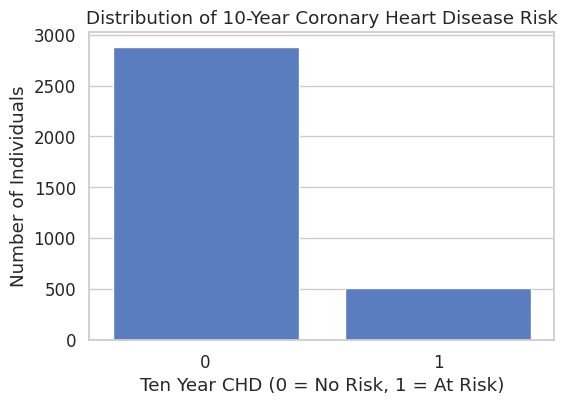

In [119]:
# Chart - 1 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 1
# Visualizing the distribution of the target variable
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals for each class of the target variable
sns.countplot(
    x='TenYearCHD',
    data=df_wrangle
)

# setting the title of the chart to describe the visualization
plt.title('Distribution of 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to explain target class meaning
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* The target variable TenYearCHD defines the core objective of this project—predicting whether an individual is at risk of developing coronary heart disease within the next ten years.

* A count plot is chosen because it clearly shows the frequency distribution of each class in a binary classification problem, helping assess class balance, which directly influences model selection, evaluation strategy, and performance interpretation.

###### 2. What is/are the insight(s) found from the chart?

From the chart, it is clearly observed that:

* The number of individuals not at risk (TenYearCHD = 0) is significantly higher than those at risk (TenYearCHD = 1).

* This indicates a strong class imbalance, where the minority class (at-risk individuals) represents a much smaller portion of the dataset.

* This imbalance suggests that the dataset does not have an equal representation of both outcome classes, which is a common characteristic of real-world healthcare data

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Early identification of class imbalance allows the use of appropriate modeling techniques such as class weighting, resampling methods, or threshold tuning.

* Evaluation metrics like recall, precision, F1-score, and ROC-AUC can be prioritized over accuracy to ensure that high-risk patients are not missed.

* In a healthcare context, correctly identifying at-risk individuals enables early intervention, preventive care, and better allocation of medical resources.


**Potential Negative Impact if Ignored:**

* If class imbalance is ignored, a model may achieve high accuracy by predominantly predicting the majority class while failing to detect high-risk individuals.

* This can result in false negatives, where patients who are actually at risk are classified as low risk, leading to delayed diagnosis and adverse health outcomes.

* Such failures can negatively impact patient safety, healthcare costs, and trust in predictive systems.


**Conclusion :**

* This chart establishes a critical foundation for the project by revealing class imbalance in the target variable.

* Addressing this imbalance appropriately will be essential for building a reliable, clinically meaningful, and ethically responsible cardiovascular risk prediction model.

##### Chart 2 - Distribution of age

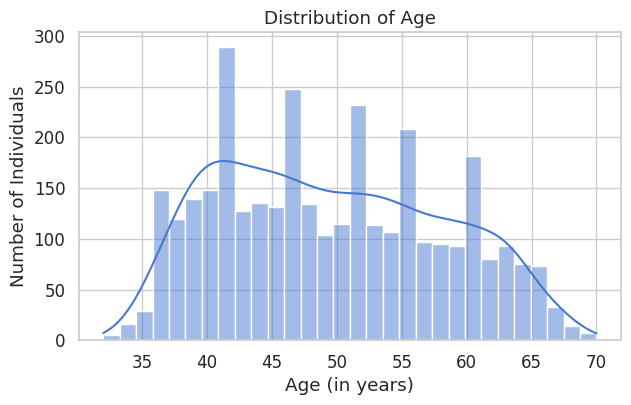

In [120]:
# Chart - 2 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 2
# Visualizing the distribution of age
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of age using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='age',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Age')

# labeling the x-axis to represent age in years
plt.xlabel('Age (in years)')

# labeling the y-axis to represent frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age is a fundamental demographic variable and one of the strongest known risk factors for cardiovascular disease.

* A **histogram with KDE (Kernel Density Estimate)** is chosen because it effectively shows:

  * The overall distribution of age values

  * The concentration of individuals across age ranges

  * The shape, spread, and skewness of the data

* This visualization helps in understanding whether the dataset represents a specific age group disproportionately and whether age-related patterns can influence cardiovascular risk prediction.

###### 2. What is/are the insight(s) found from the chart?

From the observed distribution:

* The age values range approximately from the early 30s to around 70 years.

* The dataset shows a higher concentration of individuals between 40 and 60 years, indicating that middle-aged adults are the dominant group.

* The distribution appears slightly right-skewed, with fewer individuals at the extreme higher age range.

* Very young individuals (below 35) and very old individuals (above 65) are underrepresented.

This suggests that the dataset primarily focuses on a middle-aged population, which is a critical age group for cardiovascular risk assessment.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Since cardiovascular risk increases with age, the strong representation of individuals aged 40–60 enhances the model’s ability to learn meaningful age-related risk patterns.

* Healthcare providers can use such models to design age-specific screening and prevention programs targeting middle-aged adults, potentially reducing long-term cardiac events.

**Potential Negative Impact:**

* The underrepresentation of younger and older age groups may limit the model’s generalizability for populations outside the dominant age range.

* Predictions for very young or elderly individuals may be less reliable, which could affect decision-making if the model is applied universally without proper validation.


**Conclusion :**

* The age distribution indicates a dataset focused mainly on middle-aged individuals, aligning well with cardiovascular risk studies.

* However, care must be taken when applying the model to age groups that are sparsely represented.

##### Chart 3 - Distribution of sex

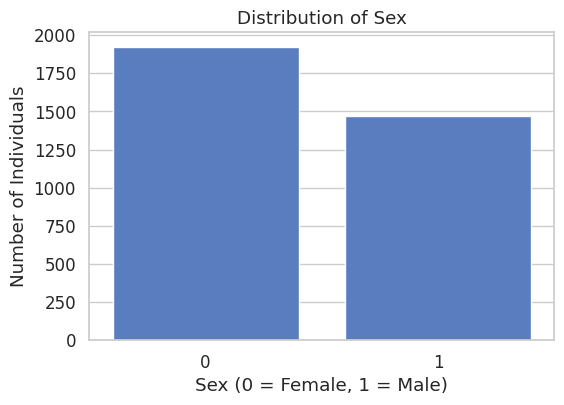

In [121]:
# Chart - 3 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 3
# Visualizing the distribution of sex
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals by sex
sns.countplot(
    x='sex',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Sex')

# labeling the x-axis to represent sex categories
plt.xlabel('Sex (0 = Female, 1 = Male)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()



###### 1. Why did you pick the specific chart?

* Sex is a key demographic variable and an important biological factor influencing cardiovascular risk.

* A count plot is selected because it clearly displays the distribution of categorical binary variables, allowing us to understand whether the dataset is gender-balanced or skewed toward a particular group.

* This understanding is essential before drawing conclusions or building predictive models.

###### 2. What is/are the insight(s) found from the chart?

From the chart, it is observed that:

* The dataset contains more female individuals (sex = 0) than male individuals (sex = 1).

* However, the difference between the two groups is not extreme, indicating a moderately balanced gender distribution.

* Both male and female populations are sufficiently represented, which is beneficial for learning gender-specific cardiovascular risk patterns.

This suggests that the dataset captures information from both genders reasonably well, though females form a slightly larger portion of the sample.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* A reasonably balanced gender distribution allows the model to learn meaningful relationships between sex and cardiovascular risk.

* Healthcare providers can use such insights to design gender-specific risk assessment strategies and preventive programs.

* The presence of both genders improves the fairness and applicability of the predictive model across populations.

**Potential Negative Impact:**

* Since males are slightly underrepresented compared to females, the model may learn slightly weaker patterns for male-specific risk factors.

* If gender imbalance is ignored during evaluation, predictions for the underrepresented group may be less reliable.


**Conclusion**

* The sex distribution shows a slightly higher representation of females but maintains sufficient balance to support gender-aware cardiovascular risk modeling.

* Careful validation will ensure that predictions remain robust for both genders

##### Chart 4 - Distribution of smoking status

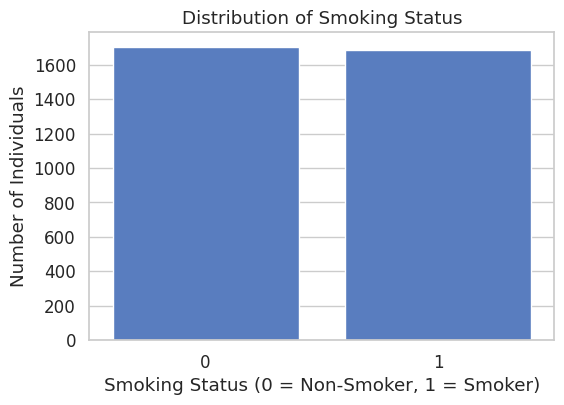

In [122]:
# Chart - 4 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 4
# Visualizing the distribution of smoking status
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals based on smoking status
sns.countplot(
    x='is_smoking',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Smoking Status')

# labeling the x-axis to represent smoking categories
plt.xlabel('Smoking Status (0 = Non-Smoker, 1 = Smoker)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Smoking status is a critical lifestyle factor directly linked to cardiovascular disease risk.

* A count plot is chosen because is_smoking is a binary categorical variable, and this chart clearly shows how the population is distributed between smokers and non-smokers.

* Understanding this distribution is essential before analyzing its relationship with heart disease risk.

###### 2. What is/are the insight(s) found from the chart?

From the chart, it is observed that:

* The number of smokers (1) and non-smokers (0) in the dataset is almost equal.

* There is no strong imbalance between the two groups, indicating that both smoking and non-smoking populations are well represented.

This balanced distribution suggests that the dataset captures lifestyle diversity effectively, which is beneficial for learning the impact of smoking on cardiovascular risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* A balanced representation of smokers and non-smokers enables the model to learn meaningful and unbiased patterns related to smoking behavior.

* Healthcare organizations can use insights from such models to design targeted smoking-cessation and prevention programs.

* The model’s predictions related to smoking status are likely to be more reliable due to adequate sample size for both categories.

**Potential Negative Impact:**

* While the distribution is balanced, smoking intensity (e.g., number of cigarettes per day) varies across individuals and is not captured by this chart.

* Relying solely on smoking status without considering smoking intensity could oversimplify risk estimation if not complemented by other variables.


**Conclusion :**

* The smoking status distribution is well balanced, strengthening the dataset’s ability to model smoking-related cardiovascular risk.

* However, deeper insights will emerge when smoking intensity and its interaction with other clinical variables are explored.

##### Chart 5 - Distribution of education levels

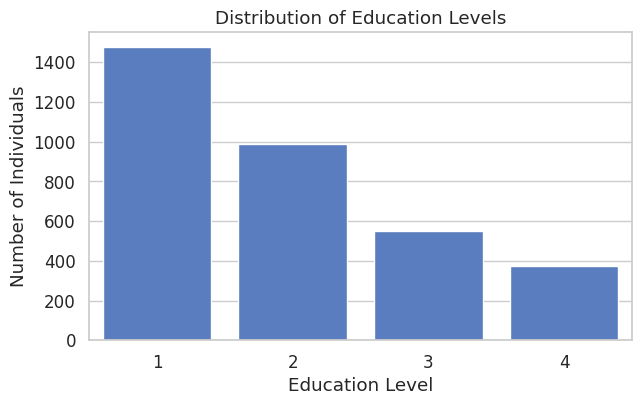

In [123]:
# Chart - 5 visualization code


# ============================================================
# 📊 Univariate Analysis – Chart 5
# Visualizing the distribution of education levels
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the count of individuals for each education level
sns.countplot(
    x='education',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Education Levels')

# labeling the x-axis to represent education categories
plt.xlabel('Education Level')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Education level is an ordinal categorical variable that often acts as a proxy for socioeconomic status, health awareness, and access to healthcare.

* A count plot is chosen because it clearly displays how individuals are distributed across discrete education categories, allowing us to understand whether certain education levels dominate the dataset and whether the variable is suitably represented for further analysis.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart, the following insights are evident:

* **Education level 1** has the highest number of individuals in the dataset.

* The count of individuals **decreases progressively** as education level increases from 1 to 4.

* **Education level 4** has the smallest representation, indicating fewer individuals with the highest education level.

* The distribution is **skewed toward lower education levels**, suggesting that a large portion of the dataset belongs to comparatively lower socioeconomic or educational groups.

This indicates that education is not uniformly distributed across the population and shows a clear ordinal trend.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Understanding the dominance of lower education levels helps healthcare providers and policymakers design targeted awareness and prevention programs for populations that may have limited health literacy.

* The model can learn education-related risk patterns more effectively for the most represented groups, improving prediction reliability for a large segment of the population.

* Education can be used as an important feature to identify vulnerable groups that may benefit from early cardiovascular screening.


**Potential Negative Impact:**

* The relatively low representation of higher education levels (especially level 4) may limit the model’s ability to learn strong patterns for this group.

* Predictions for individuals in underrepresented education categories may be less stable, which could reduce generalizability if the model is applied to populations with different educational distributions.

**Conclusion :**

* The education variable shows a clear skew toward lower education levels, highlighting potential socioeconomic disparities in the dataset.

* This insight is valuable for both predictive modeling and designing targeted public health interventions, though care must be taken when interpreting results for underrepresented education groups.

##### Chart 6 - Distribution of systolic blood pressure

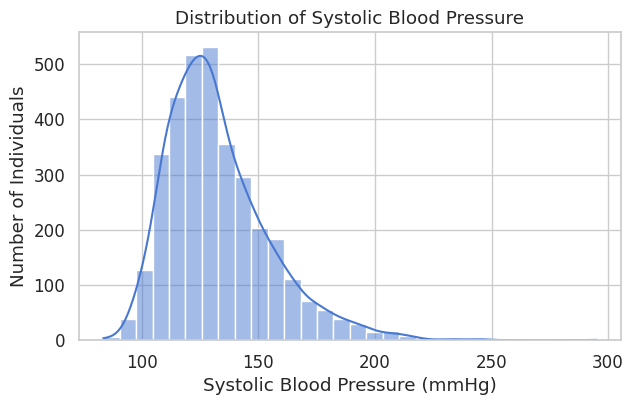

In [124]:
# Chart - 6 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 6
# Visualizing the distribution of systolic blood pressure
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of systolic blood pressure using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='sysBP',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Systolic Blood Pressure')

# labeling the x-axis to represent systolic blood pressure values
plt.xlabel('Systolic Blood Pressure (mmHg)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Systolic blood pressure (sysBP) is a critical clinical indicator for cardiovascular health and one of the strongest predictors of heart disease.

* A histogram with KDE is chosen because it effectively shows:

  * The distribution and spread of systolic blood pressure values

  * The central tendency and skewness

  * The presence of extreme or outlier values

* This visualization helps in understanding whether the population largely falls within normal, elevated, or hypertensive ranges.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart, the following insights are evident:

* Most individuals have systolic blood pressure values concentrated roughly between 110 mmHg and 150 mmHg.

* The distribution shows a right-skewed pattern, indicating the presence of individuals with higher systolic blood pressure.

* A long tail extending toward higher values (above ~180 mmHg) suggests the presence of severely hypertensive individuals.

* Very few individuals fall at extremely low systolic blood pressure levels.

This indicates that while the majority of the population lies in a moderate range, a significant subset exhibits elevated or high systolic blood pressure.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Identifying a right-skewed distribution with high systolic blood pressure values helps healthcare providers flag high-risk individuals for early intervention.

* Models trained on this data can learn meaningful patterns associated with hypertension-related cardiovascular risk.

* Public health programs can prioritize blood pressure screening and management initiatives for populations showing elevated systolic values.


**Potential Negative Impact:**

* The presence of extreme high values may introduce outliers that could disproportionately influence certain machine learning algorithms.

* If not handled carefully during preprocessing or modeling, these extreme values may lead to biased predictions or reduced model stability.


**Conclusion :**

* The systolic blood pressure distribution highlights a population with a wide range of blood pressure levels, including a notable right-skew with high-risk individuals.

* This reinforces the importance of blood pressure as a key predictive feature while also signaling the need for careful handling of extreme values during modeling.

##### Chart 7 - Distribution of diastolic blood pressure

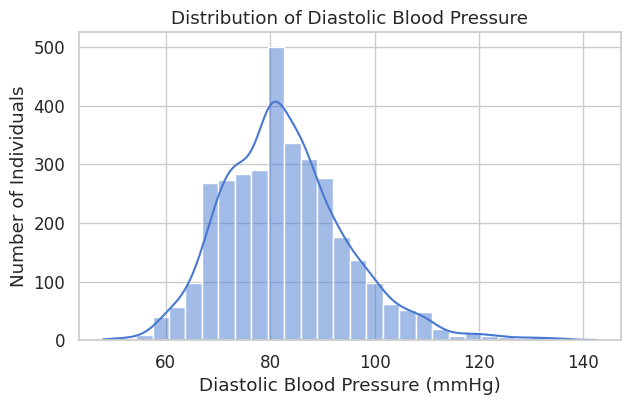

In [125]:
# Chart - 7 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 7
# Visualizing the distribution of diastolic blood pressure
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of diastolic blood pressure using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='diaBP',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Diastolic Blood Pressure')

# labeling the x-axis to represent diastolic blood pressure values
plt.xlabel('Diastolic Blood Pressure (mmHg)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Diastolic blood pressure (diaBP) is a critical physiological measure used to diagnose hypertension and assess cardiovascular health.

* A histogram with KDE is selected because it helps visualize:

  * The spread and central tendency of diastolic blood pressure values

  * The overall shape of the distribution


* The presence of skewness or extreme values
This chart is essential to understand whether the population largely falls within normal, elevated, or hypertensive diastolic pressure ranges.

###### 2. What is/are the insight(s) found from the chart?

From the observed distribution in the chart:

* Most individuals have diastolic blood pressure values concentrated roughly between 70 mmHg and 90 mmHg.

* The peak of the distribution appears around 75–80 mmHg, indicating the most common diastolic pressure range.

* The distribution shows a slight right skew, with a tail extending toward higher values above 100 mmHg.

* A small number of individuals exhibit very high diastolic blood pressure (above ~110 mmHg), indicating potential hypertension cases.

* Very low diastolic blood pressure values are relatively rare.


This suggests that while the majority of the population lies within or near the normal diastolic range, a subset of individuals is at elevated cardiovascular risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Identifying the concentration of individuals with normal-to-elevated diastolic blood pressure allows healthcare providers to focus preventive care on borderline cases before they progress to severe hypertension.

* Predictive models can leverage this variable effectively, as it shows meaningful variation across individuals.

* Public health initiatives can prioritize blood pressure monitoring programs based on these insights.


**Potential Negative Impact:**

* The presence of extreme high diastolic values may act as outliers and could disproportionately influence certain machine learning models if not handled properly.

* If such extreme values are ignored or improperly treated, model predictions may become unstable or biased.


**Conclusion :**

* The diastolic blood pressure distribution shows that most individuals fall within a clinically reasonable range, while a smaller subset exhibits elevated values associated with higher cardiovascular risk.

* This reinforces the importance of diaBP as a strong predictive feature and highlights the need for careful handling of extreme values during modeling.

##### Chart 8 - Distribution of body mass index (BMI)

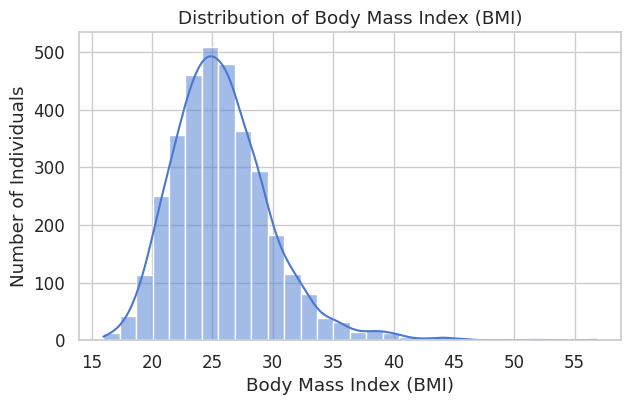

In [126]:
# Chart - 8 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 8
# Visualizing the distribution of body mass index (BMI)
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of BMI using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='BMI',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Body Mass Index (BMI)')

# labeling the x-axis to represent BMI values
plt.xlabel('Body Mass Index (BMI)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Body Mass Index (BMI) is a widely used clinical indicator for assessing obesity and overweight status, both of which are strongly associated with cardiovascular risk.

* A histogram with KDE is chosen because it clearly shows:

  * The distribution and spread of BMI values

  * The central tendency and skewness

  * The presence of extreme or outlier BMI values

* This visualization helps understand whether the population largely falls into normal, overweight, or obese BMI categories.

###### 2. What is/are the insight(s) found from the chart?

From the observed BMI distribution:

* Most individuals have BMI values concentrated roughly between 22 and 30.

* The peak of the distribution appears around 24–26, indicating that a large portion of individuals fall near the upper end of the normal or early overweight range.

* The distribution is right-skewed, with a long tail extending toward higher BMI values.

* A smaller number of individuals have very high BMI values (above ~35), indicating obesity.

* Very low BMI values are rare, suggesting underweight individuals are minimally represented.

This indicates that overweight and obesity are prevalent in the dataset, which is clinically relevant for cardiovascular risk analysis.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The presence of a large overweight and obese population allows the model to learn strong BMI-related cardiovascular risk patterns.

* Healthcare providers can use such insights to design lifestyle intervention programs focusing on weight management.

* Public health strategies can prioritize obesity prevention as a key factor in reducing long-term heart disease risk.

**Potential Negative Impact:**

* Extreme BMI values may act as outliers and could influence model performance if not handled carefully during modeling.

* If BMI is used without considering related factors such as age, blood pressure, and glucose, it may oversimplify risk estimation.

**Conclusion :**

The BMI distribution highlights a population with a significant proportion of individuals in the overweight and obese ranges, reinforcing BMI as a critical feature for cardiovascular risk prediction while also signaling the need for careful handling of extreme values.

##### Chart 9 - Distribution of resting heart rate

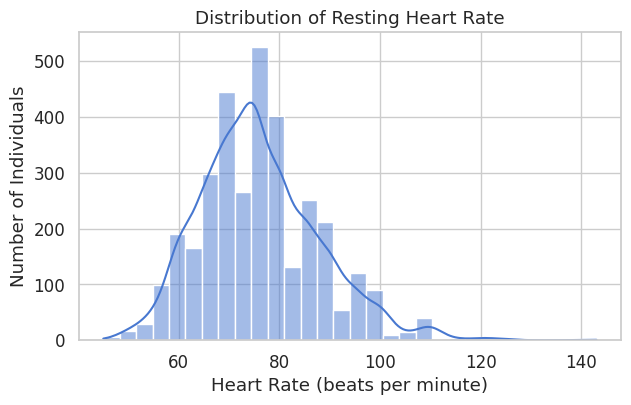

In [127]:
# Chart - 9 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 9
# Visualizing the distribution of resting heart rate
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of heart rate using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='heartRate',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Resting Heart Rate')

# labeling the x-axis to represent heart rate values
plt.xlabel('Heart Rate (beats per minute)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Resting heart rate is an important physiological indicator of cardiovascular health and overall fitness.

* A histogram with KDE is chosen because it helps visualize:

  * The distribution and spread of resting heart rate values

  * The most common heart rate range in the population

* The presence of skewness or extreme heart rate values
This chart is useful to understand whether the dataset primarily consists of individuals with normal, elevated, or abnormal resting heart rates.

###### 2. What is/are the insight(s) found from the chart?

Based on the observed distribution:

* Most individuals have resting heart rates concentrated roughly between 60 and 85 beats per minute (bpm).

* The peak of the distribution appears around 70–75 bpm, which lies within the clinically normal resting heart rate range.

* The distribution shows a slight right skew, with a tail extending toward higher heart rate values.

* A small number of individuals exhibit very high resting heart rates (above ~100 bpm), which may indicate potential cardiovascular stress or underlying health conditions.

* Very low heart rate values are rare, suggesting limited representation of individuals with bradycardia.

This indicates that while the majority of individuals fall within a normal resting heart rate range, a subset shows elevated heart rates that could be clinically significant.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The presence of a well-distributed normal heart rate range allows predictive models to learn meaningful baseline patterns.

* Elevated heart rate values can help identify individuals who may require further clinical evaluation or lifestyle intervention.

* Healthcare systems can leverage such insights for early screening and preventive cardiovascular care.


**Potential Negative Impact:**

* Extreme heart rate values may act as outliers and could influence model performance if not handled carefully.

* If resting heart rate is analyzed in isolation without considering physical activity levels or medication usage, it may lead to incomplete risk interpretation.


**Conclusion :**

* The resting heart rate distribution suggests a population largely within the normal physiological range, with a smaller subset exhibiting elevated values associated with increased cardiovascular risk.

* This reinforces heart rate as a meaningful feature while highlighting the importance of contextual interpretation during modeling.

##### Chart 10 - Distribution of total cholesterol

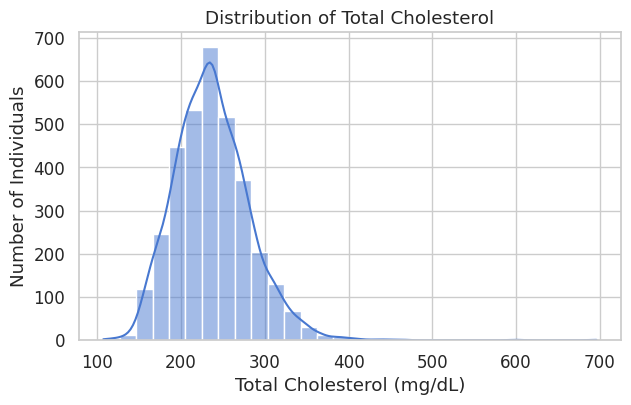

In [128]:
# Chart - 10 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 10
# Visualizing the distribution of total cholesterol
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of total cholesterol using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='totChol',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Total Cholesterol')

# labeling the x-axis to represent total cholesterol values
plt.xlabel('Total Cholesterol (mg/dL)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Total cholesterol is a key biochemical indicator directly associated with cardiovascular disease risk.

* A histogram with KDE is chosen because it helps visualize:

  * The distribution and spread of cholesterol levels

  * The central tendency and skewness of the data

  * The presence of extreme cholesterol values

* This visualization allows us to understand whether most individuals fall within normal, borderline, or high cholesterol ranges.

###### 2. What is/are the insight(s) found from the chart?

From the observed distribution in the chart:

* Most individuals have total cholesterol values concentrated roughly between 180 mg/dL and 280 mg/dL.

* The peak of the distribution appears around 220–240 mg/dL, which lies close to the clinically borderline-to-high cholesterol range.

* The distribution is right-skewed, with a long tail extending toward higher cholesterol values.

* A small number of individuals show very high cholesterol levels (above ~350 mg/dL), indicating elevated cardiovascular risk.

* Extremely low cholesterol values are rare in the dataset.


This suggests that a significant portion of the population has borderline or elevated cholesterol levels.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The presence of a wide range of cholesterol values allows the predictive model to learn meaningful risk patterns related to lipid levels.

* Healthcare providers can use such insights to prioritize cholesterol screening and lipid-management programs.

* Public health initiatives can target populations with elevated cholesterol to reduce long-term cardiovascular disease burden.


**Potential Negative Impact:**

* Extreme cholesterol values may act as outliers and could influence model training if not handled carefully.

* If cholesterol is analyzed without considering other related factors such as age, blood pressure, and diabetes status, risk interpretation may be incomplete.


**Conclusion :**

* The total cholesterol distribution shows a right-skewed pattern with a substantial number of individuals in the borderline-to-high cholesterol range.

* This reinforces total cholesterol as a critical feature for cardiovascular risk prediction while highlighting the need for careful handling of extreme values during modeling.

##### Chart 11 - Distribution of blood glucose levels

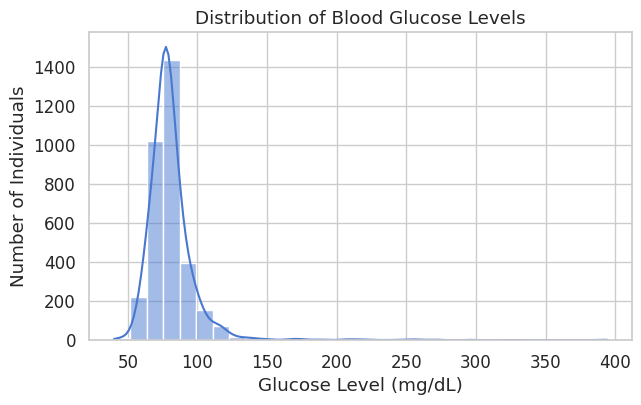

In [129]:
# Chart - 11 visualization code


# ============================================================
# 📊 Univariate Analysis – Chart 11
# Visualizing the distribution of blood glucose levels
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of glucose levels using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='glucose',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Blood Glucose Levels')

# labeling the x-axis to represent glucose values
plt.xlabel('Glucose Level (mg/dL)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Blood glucose level is a key metabolic indicator closely linked to diabetes, which is a major risk factor for cardiovascular disease.

* A histogram with KDE is chosen because it allows clear visualization of:

  * The distribution and concentration of glucose values

  * The central tendency and spread

  * The presence of skewness and extreme glucose values

* This chart helps in understanding whether the population largely falls within normal, prediabetic, or diabetic glucose ranges.

###### 2. What is/are the insight(s) found from the chart?

From the observed distribution:

* Most individuals have glucose levels concentrated roughly between 70 mg/dL and 100 mg/dL, which corresponds to the normal fasting glucose range.

* The peak of the distribution appears around 80–90 mg/dL, indicating that a large portion of individuals have normal glucose levels.

* The distribution is strongly right-skewed, with a long tail extending toward higher glucose values.

* A small subset of individuals shows very high glucose levels (above ~140 mg/dL), suggesting possible diabetic or uncontrolled glucose conditions.

* Extremely low glucose values are rare in the dataset.

This indicates that while most individuals maintain normal glucose levels, there is a clinically important minority at elevated metabolic risk.


###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Identifying individuals with elevated glucose levels enables early detection of diabetes-related cardiovascular risk.

* Predictive models can leverage glucose as a strong indicator to improve risk stratification accuracy.

* Healthcare systems can design targeted screening and intervention programs for populations with abnormal glucose levels.

**Potential Negative Impact:**

* The presence of extreme glucose values may act as outliers and could influence model performance if not addressed carefully.

* If glucose measurements are used without context (e.g., fasting vs non-fasting), risk interpretation may be less precise.


**Conclusion :**

* The glucose distribution reveals a largely healthy population with normal glucose levels, alongside a smaller high-risk group exhibiting elevated values.

* This reinforces glucose as a crucial feature for cardiovascular risk prediction while highlighting the need for careful handling of extreme values during modeling.




##### Chart 12 - Distribution of blood pressure medication status

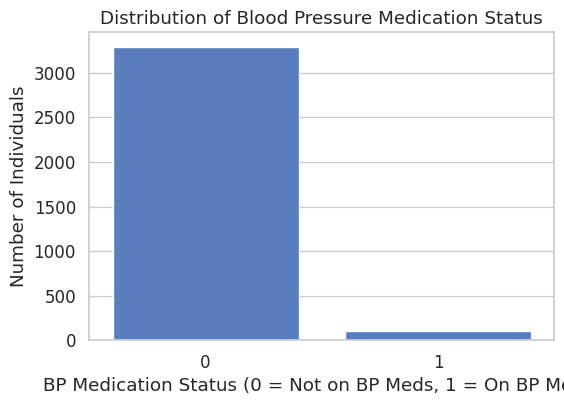

In [130]:
# Chart - 12 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 12
# Visualizing the distribution of blood pressure medication status
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals based on BP medication status
sns.countplot(
    x='BPMeds',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Blood Pressure Medication Status')

# labeling the x-axis to represent BP medication categories
plt.xlabel('BP Medication Status (0 = Not on BP Meds, 1 = On BP Meds)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* BPMeds indicates whether an individual is taking blood pressure medication, which is an important clinical factor reflecting existing hypertension management.

* A count plot is chosen because BPMeds is a binary categorical variable, and this chart clearly shows the proportion of individuals on medication versus those not receiving treatment.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart:

* A large majority of individuals are not on blood pressure medication (BPMeds = 0).

* Only a very small proportion of individuals are on BP medication (BPMeds = 1).

* This indicates a highly imbalanced distribution for this variable.

The imbalance suggests that most individuals in the dataset are either not diagnosed with hypertension or are not undergoing pharmacological treatment, while only a limited subset is actively managing blood pressure through medication.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Identifying a small treated population helps healthcare providers recognize gaps in hypertension treatment coverage.

* The model can potentially learn the impact of untreated versus treated hypertension on cardiovascular risk.

* These insights can guide policy decisions and public health initiatives focused on improving diagnosis and medication adherence.

**Potential Negative Impact:**

* The extreme class imbalance may reduce the predictive power of this variable during model training.

* Models may struggle to learn meaningful patterns related to BP medication usage due to limited representation.

* If imbalance is not handled carefully, predictions for medicated individuals may be less reliable.


**Conclusion :**

* The blood pressure medication status shows a strong imbalance, with most individuals not on treatment.

* While this highlights potential public health gaps, it also signals the need for careful modeling strategies to ensure reliable predictions for the underrepresented medicated group.

##### Chart 13 - Distribution of cigarettes smoked per day

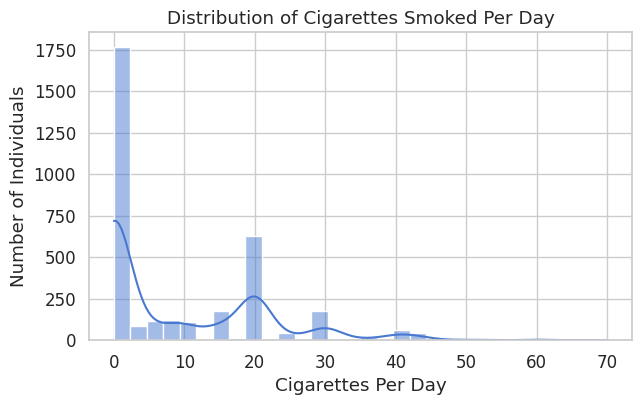

In [131]:
# Chart - 13 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 13
# Visualizing the distribution of cigarettes smoked per day
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of cigarettes per day using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='cigsPerDay',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Cigarettes Smoked Per Day')

# labeling the x-axis to represent number of cigarettes smoked per day
plt.xlabel('Cigarettes Per Day')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* cigsPerDay represents smoking intensity, which provides more granular information than smoking status alone.

* A histogram with KDE is chosen because it helps visualize:

  * How many cigarettes individuals smoke per day

  * The concentration of light, moderate, and heavy smokers

  * The presence of skewness and extreme smoking behavior

* This chart is important for understanding lifestyle-related cardiovascular risk beyond a simple smoker/non-smoker classification.

###### 2. What is/are the insight(s) found from the chart?

From the observed distribution:

* A very large spike at 0 cigarettes per day is visible, indicating a substantial number of non-smokers in the dataset.

* Among smokers, most individuals smoke between 10 and 25 cigarettes per day, suggesting a concentration of moderate smokers.

* The distribution is highly right-skewed, with a long tail extending toward higher cigarette consumption.

* A small number of individuals smoke more than 30 cigarettes per day, representing heavy smokers.
Extremely high values (above ~50 cigarettes per day) are rare.

This shows a mixed population consisting largely of non-smokers, followed by moderate smokers, with relatively few heavy smokers.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Differentiating between non-smokers, moderate smokers, and heavy smokers allows the model to capture nuanced smoking-related cardiovascular risk.

* Healthcare providers can use this information to design targeted smoking-cessation programs based on smoking intensity.

* Public health strategies can prioritize intervention for heavy smokers, who represent a high-risk subgroup.


**Potential Negative Impact:**

* The strong skew and concentration at zero may dominate the distribution, potentially reducing the influence of smoking intensity for smokers if not handled carefully during modeling.

* Extreme smoking values may act as outliers and could negatively impact certain machine learning algorithms.


**Conclusion :**

* The distribution of cigarettes smoked per day reveals a population dominated by non-smokers, followed by moderate smokers, with a small subset of heavy smokers.

* This reinforces smoking intensity as an important yet unevenly distributed risk factor that requires careful modeling consideration.

##### Chart 14 - Distribution of Prevalent Hypertension

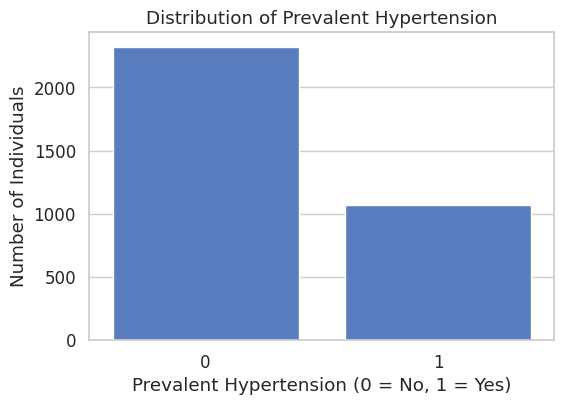

In [132]:
# Chart - 14 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 14
# Visualizing the distribution of prevalent hypertension
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals based on hypertension status
sns.countplot(
    x='prevalentHyp',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Prevalent Hypertension')

# labeling the x-axis to represent hypertension categories
plt.xlabel('Prevalent Hypertension (0 = No, 1 = Yes)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* prevalentHyp indicates whether an individual already has a history of hypertension, which is one of the strongest and most established risk factors for cardiovascular disease.

* A count plot is chosen because this variable is binary, and the chart clearly shows how the population is split between individuals with and without pre-existing hypertension.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart:

* A larger proportion of individuals do not have prevalent hypertension (prevalentHyp = 0).

* A substantial minority of individuals have prevalent hypertension (prevalentHyp = 1).

* While the dataset is skewed toward non-hypertensive individuals, the hypertensive group is significant in size, not negligible.

* This indicates that the dataset includes a meaningful number of individuals who already have hypertension, which is valuable for learning cardiovascular risk patterns.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The presence of a sizable hypertensive population enables predictive models to learn how existing hypertension contributes to future coronary heart disease risk.

* Healthcare providers can use such insights to prioritize follow-ups and preventive interventions for hypertensive patients.

* Public health programs can focus on hypertension management as a key strategy for reducing long-term cardiovascular events.


**Potential Negative Impact:**

* The imbalance between hypertensive and non-hypertensive individuals may slightly bias the model toward the majority group if not addressed properly.

* If the hypertensive group is not sufficiently emphasized during modeling, the model may underestimate risk for individuals with existing hypertension.


**Conclusion :**

* The prevalent hypertension distribution shows that while most individuals do not have hypertension, a considerable portion already does.

* This reinforces hypertension as a critical predictor for cardiovascular risk and highlights the need for careful modeling to ensure reliable predictions for hypertensive individuals.

##### Chart 15 - Distribution of Diabetes Status

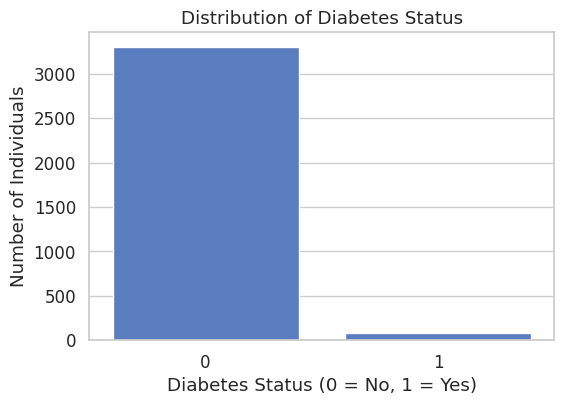

In [133]:
# Chart - 15 visualization code


# ============================================================
# 📊 Univariate Analysis – Chart 15
# Visualizing the distribution of diabetes status
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals based on diabetes status
sns.countplot(
    x='diabetes',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Diabetes Status')

# labeling the x-axis to represent diabetes categories
plt.xlabel('Diabetes Status (0 = No, 1 = Yes)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* diabetes is a critical metabolic condition and one of the strongest established risk factors for cardiovascular disease.

* A count plot is chosen because diabetes status is a binary categorical variable, and this chart clearly shows how the population is distributed between diabetic and non-diabetic individuals.

* Understanding this distribution is essential before analyzing its relationship with cardiovascular outcomes.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart:

* An overwhelming majority of individuals do not have diabetes (diabetes = 0).

* Only a very small fraction of individuals are diabetic (diabetes = 1).

* This indicates a highly imbalanced distribution for the diabetes variable.

The dataset therefore contains very limited representation of diabetic individuals compared to non-diabetic individuals.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Even though the diabetic population is small, its presence is clinically important, as diabetes significantly elevates cardiovascular risk.

* The model can still learn strong risk signals from diabetic cases, especially when combined with glucose, BMI, and blood pressure variables.

* Healthcare decision-makers can use such insights to prioritize cardiovascular screening among diabetic individuals.

**Potential Negative Impact:**

* The extreme class imbalance may limit the model’s ability to generalize diabetes-related risk patterns.

* If not handled carefully, the model may underperform for diabetic individuals due to their low representation.

* Specialized techniques (class weighting or careful evaluation metrics) may be required during modeling to avoid bias.


**Conclusion :**

* The diabetes distribution shows that most individuals in the dataset are non-diabetic, with only a small high-risk diabetic subgroup.

* While this reflects real-world population trends, it highlights the need for careful modeling strategies to ensure reliable cardiovascular risk prediction for diabetic individuals.

##### Chart 16 - Distribution of Prevalent Stroke

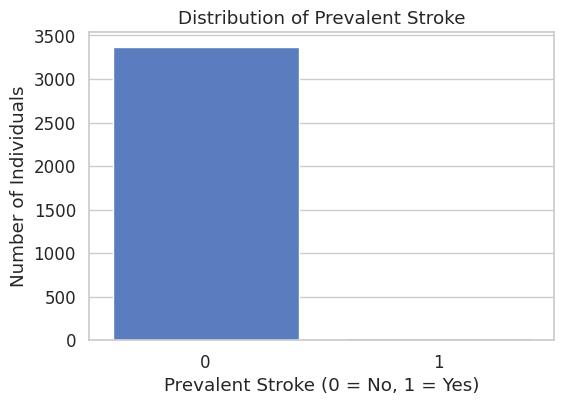

In [134]:
# Chart - 16 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 16
# Visualizing the distribution of prevalent stroke history
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals based on stroke history
sns.countplot(
    x='prevalentStroke',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Prevalent Stroke')

# labeling the x-axis to represent stroke history categories
plt.xlabel('Prevalent Stroke (0 = No, 1 = Yes)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* prevalentStroke indicates whether an individual has a history of stroke, which is a serious cardiovascular event and a strong clinical risk marker for future heart disease.

* A count plot is chosen because this variable is binary, and the chart clearly shows how frequently prior stroke cases appear in the dataset compared to non-stroke cases.

* Understanding this distribution is important to assess how well prior stroke history is represented in the data.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart:

* Almost all individuals have no history of stroke (prevalentStroke = 0).

* The number of individuals with a prior stroke (prevalentStroke = 1) is extremely small or nearly absent.

* This shows an extreme class imbalance for the stroke history variable.

The dataset therefore contains very limited representation of individuals with prior stroke, making this a rare event feature.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Even though prior stroke cases are rare, their presence is clinically significant, as stroke history greatly increases cardiovascular risk.

* The model can still use this variable as a high-risk signal when it occurs, helping identify individuals who require urgent or specialized care.

* Healthcare systems can use this insight to emphasize post-stroke monitoring and preventive strategies.

**Potential Negative Impact:**

* The extreme imbalance means the model may struggle to learn meaningful patterns related to prior stroke history.

* Predictions involving this variable may be unreliable due to the very small sample size.

* Without careful modeling strategies, the feature may contribute little predictive power or introduce instability.


**Conclusion :**

* The prevalent stroke distribution highlights that prior stroke is a rare event in the dataset.

* While this reflects real-world population trends, it also signals the need for careful handling during modeling to ensure that this high-risk but low-frequency feature is interpreted correctly.

#### Bivariate Analysis

##### Chart 17 - Rrelationship between age and 10-year CHD risk

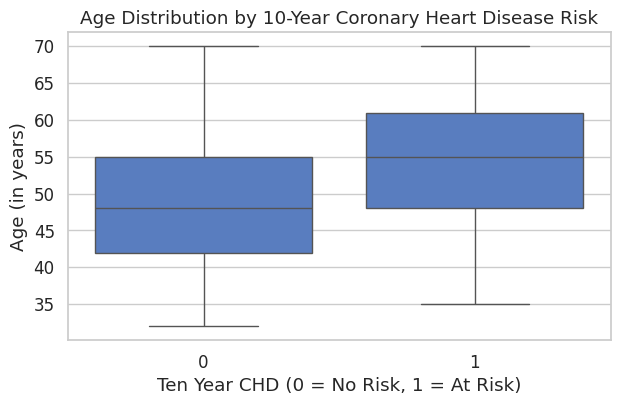

In [135]:
# Chart - 17 visualization code


# ============================================================
# 📊 Bivariate Analysis – Chart 1
# Visualizing the relationship between age and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare age distribution across CHD classes
sns.boxplot(
    x='TenYearCHD',
    y='age',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Age Distribution by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent age in years
plt.ylabel('Age (in years)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age is a continuous numerical variable, while TenYearCHD is a binary target variable.

* A box plot is chosen because it effectively compares the distribution, median, spread, and variability of age across the two target classes.

* This makes it ideal for identifying whether age differs meaningfully between individuals who are at risk and those who are not.

###### 2. What is/are the insight(s) found from the chart?

* Individuals at risk of coronary heart disease (TenYearCHD = 1) have a higher median age compared to those not at risk (TenYearCHD = 0).

* The interquartile range (IQR) for the at-risk group is shifted toward older ages, indicating that CHD risk increases with age.

* Younger individuals are more concentrated in the non-risk group, while older individuals are more prevalent in the risk group.

* There is some overlap between the two groups, but the overall age distribution for the at-risk group is clearly higher.

This confirms a strong positive association between age and 10-year coronary heart disease risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight allows healthcare providers to prioritize age-based screening and preventive interventions.

* Predictive models can effectively use age as a strong feature to improve cardiovascular risk prediction accuracy.

* Public health policies can focus on early detection strategies for middle-aged and elderly populations to reduce long-term healthcare costs.


**Potential Negative Impact:**


* Since age is a non-modifiable factor, relying too heavily on age alone may overlook younger individuals with high risk due to lifestyle or genetic factors.

* If not combined with other clinical features, age-based predictions could lead to under-screening of younger at-risk individuals.


**Conclusion :**

* The box plot clearly demonstrates that age is a significant factor associated with increased 10-year coronary heart disease risk.

* While age alone should not drive decision-making, it plays a critical role when combined with other lifestyle and clinical variables.

##### Chart 18 - Relationship between systolic BP and 10-year CHD risk

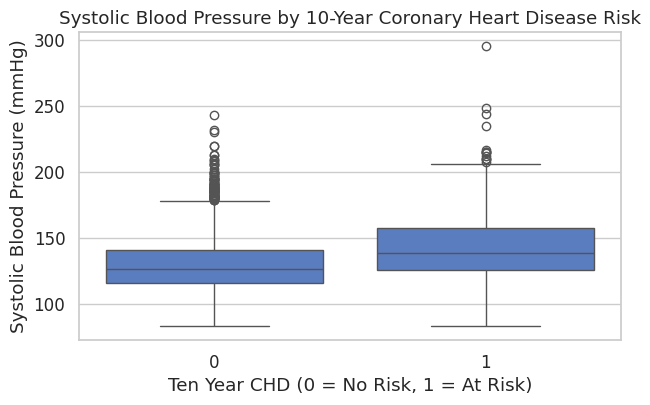

In [136]:
# Chart - 18 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 2
# Visualizing the relationship between systolic BP and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare systolic BP across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='sysBP',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Systolic Blood Pressure by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent systolic blood pressure values
plt.ylabel('Systolic Blood Pressure (mmHg)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Systolic blood pressure (sysBP) is a continuous clinical measurement and one of the most important modifiable risk factors for cardiovascular disease.

* A box plot is chosen to compare the distribution, median, spread, and presence of outliers of systolic blood pressure across the two CHD risk categories.

* This chart helps assess whether elevated systolic blood pressure is associated with higher 10-year CHD risk.

###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) show a higher median systolic blood pressure compared to those in the non-risk group.

* The overall distribution of systolic blood pressure for at-risk individuals is shifted toward higher values.

* The at-risk group exhibits greater variability and more extreme high-value outliers, indicating cases of severe hypertension.

* Although there is overlap between the two groups, higher systolic blood pressure levels are more common among individuals at risk.

* This suggests a clear positive association between elevated systolic blood pressure and 10-year coronary heart disease risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* These insights reinforce the importance of blood pressure control in preventing cardiovascular disease.

* Predictive models can leverage systolic blood pressure as a strong feature to improve CHD risk prediction.

* Healthcare providers can use this information to prioritize early intervention and monitoring for individuals with elevated systolic BP.


**Potential Negative Impact:**

* Presence of extreme outliers may skew model training if not handled properly.

* Over-reliance on systolic BP alone may overlook individuals with normal BP but other significant risk factors.

* Poor data handling of outliers could lead to unstable predictions.


**Conclusion :**

* The chart clearly indicates that higher systolic blood pressure is associated with increased 10-year coronary heart disease risk.

* While systolic BP is a powerful predictor, it should be interpreted alongside other clinical and lifestyle variables for balanced decision-making.

##### Chart 19 - Relationship between diastolic BP and 10-year CHD risk

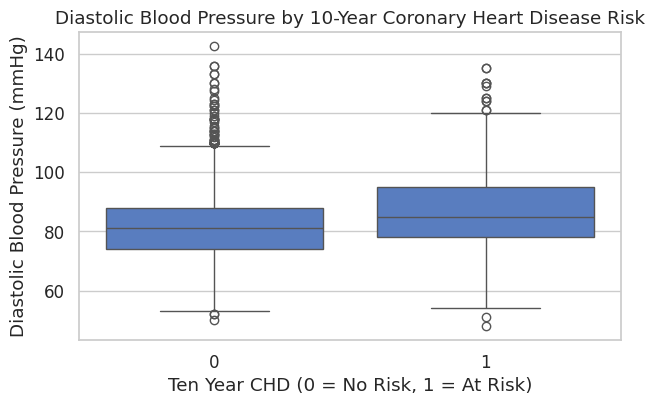

In [137]:
# Chart - 19 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 3
# Visualizing the relationship between diastolic BP and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare diastolic BP across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='diaBP',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Diastolic Blood Pressure by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent diastolic blood pressure values
plt.ylabel('Diastolic Blood Pressure (mmHg)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Diastolic blood pressure (diaBP) is a continuous cardiovascular measurement and an important indicator of vascular resistance and heart workload.

* A box plot is selected because it allows direct comparison of the distribution, median, variability, and outliers of diastolic blood pressure between individuals who are at risk and not at risk of coronary heart disease.

###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) show a slightly higher median diastolic blood pressure compared to the non-risk group.

* The distribution for the at-risk group is shifted marginally upward, indicating higher diastolic BP levels.

* Both groups exhibit several high-value outliers, but the at-risk group shows more concentration toward elevated values.

* There is notable overlap between the two groups, suggesting that diastolic BP alone is not a strong separator but still contributes to risk.

* This indicates a moderate positive association between elevated diastolic blood pressure and 10-year CHD risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* These insights highlight the importance of monitoring diastolic blood pressure alongside systolic pressure in cardiovascular risk assessment.

* Predictive models can benefit from including diastolic BP as a complementary feature to improve overall prediction robustness.

* Healthcare providers can design balanced hypertension management strategies focusing on both systolic and diastolic measures.


**Potential Negative Impact:**

* The overlapping distributions indicate limited standalone predictive power.

* Overemphasizing diastolic BP without considering other variables may lead to inaccurate risk stratification.

* Presence of outliers may require preprocessing to avoid model instability.

**Conclusion :**

* The chart shows that diastolic blood pressure is moderately higher among individuals at risk of coronary heart disease.

* While it is not a dominant predictor on its own, it plays a meaningful supporting role when combined with other cardiovascular indicators.

##### Chart 20 - Coronary Heart Disease Risk by Body Mass Index

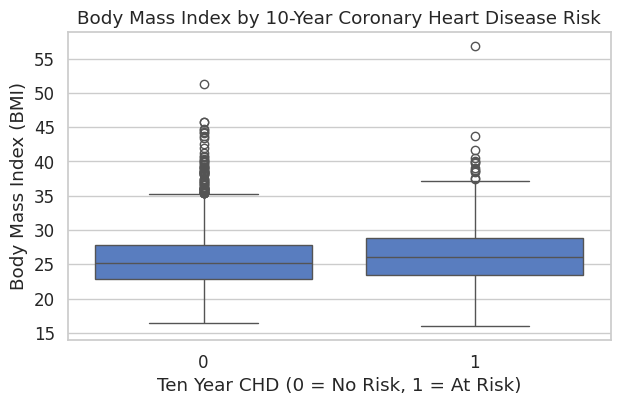

In [138]:
# Chart - 20 visualization code


# ============================================================
# 📊 Bivariate Analysis – Chart 4
# Visualizing the relationship between BMI and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare BMI distribution across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='BMI',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Body Mass Index by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent BMI values
plt.ylabel('Body Mass Index (BMI)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Body Mass Index (BMI) is a continuous numerical variable and a widely used indicator of overweight and obesity, both of which are known contributors to cardiovascular disease.

* A box plot is selected to compare the distribution, median, spread, and presence of outliers of BMI across individuals with and without 10-year coronary heart disease risk.

* This visualization helps assess whether higher body mass is associated with increased CHD risk.


###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) show a slightly higher median BMI compared to those in the non-risk group.

* The BMI distribution for the at-risk group is shifted marginally upward, indicating a tendency toward higher body mass.

* Both groups exhibit several high-BMI outliers, suggesting the presence of obese individuals in both risk categories.

* There is substantial overlap between the two distributions, indicating that BMI alone does not sharply separate the risk groups.

* Overall, BMI shows a weak to moderate positive association with 10-year coronary heart disease risk.


###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The insights reinforce the role of weight management in cardiovascular disease prevention.

* Including BMI in predictive models can help improve risk stratification when combined with blood pressure, age, and metabolic factors.

* Healthcare organizations can design lifestyle intervention programs targeting overweight and obese populations to reduce long-term CHD risk.

**Potential Negative Impact:**

* The strong overlap between BMI distributions may reduce its standalone predictive value.

* Sole reliance on BMI could overlook individuals with normal BMI but high cardiovascular risk due to other factors.

* Outliers may require careful preprocessing to prevent skewed model behavior.

**Conclusion :**

* The chart indicates that higher BMI is modestly associated with increased 10-year coronary heart disease risk.

* While BMI alone is not a decisive predictor, it contributes meaningful context when used alongside other clinical and lifestyle variables.



##### Chart 21 - Coronary Heart Disease Risk by Blood Glucose Levels

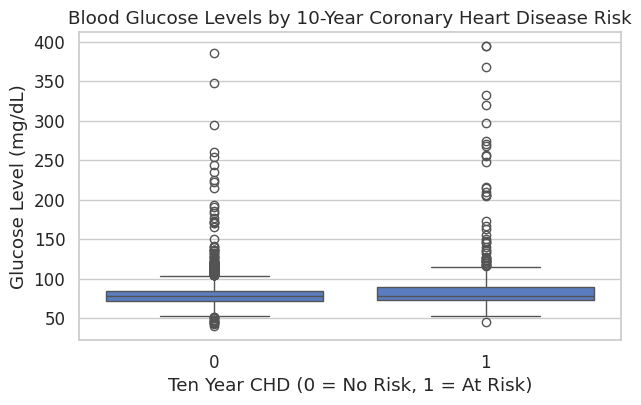

In [139]:
# Chart - 21 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 5
# Visualizing the relationship between glucose level and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare glucose levels across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='glucose',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Blood Glucose Levels by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent glucose levels
plt.ylabel('Glucose Level (mg/dL)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Blood glucose level is a continuous metabolic variable and a strong indicator of diabetes and insulin resistance, both of which are closely linked to cardiovascular disease.

* A box plot is chosen to compare the distribution, median, spread, and outliers of glucose levels between individuals who are at risk and not at risk of developing coronary heart disease within 10 years.

* This visualization helps evaluate whether elevated glucose levels are associated with higher CHD risk.

###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) have a slightly higher median glucose level compared to the non-risk group.

* The glucose distribution for the at-risk group is shifted marginally upward, indicating higher blood glucose levels among those at risk.

* The at-risk group shows more extreme high-value outliers, representing individuals with very high glucose levels.

* There is considerable overlap between the two groups, suggesting glucose alone does not sharply distinguish CHD risk but contributes meaningful information.

* Overall, glucose shows a moderate positive association with 10-year coronary heart disease risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* These findings emphasize the importance of glycemic control in reducing cardiovascular risk.

* Predictive models can benefit from including glucose as a feature, especially when combined with diabetes status, BMI, and blood pressure.

* Healthcare providers can target early interventions for individuals with elevated glucose to prevent long-term cardiovascular complications.


**Potential Negative Impact:**

* The strong presence of outliers may affect model stability if not handled carefully.

* Overlapping distributions reduce glucose’s standalone predictive power.

* If glucose values are noisy or inconsistently measured, they may introduce variance into the model.


**Conclusion :**

* The chart indicates that higher blood glucose levels are associated with increased 10-year coronary heart disease risk, although the relationship is moderate.

* Glucose is most effective as a predictive feature when combined with other metabolic and clinical variables.

##### Chart 22 - Coronary Heart Disease Risk by Total Cholesterol Levels

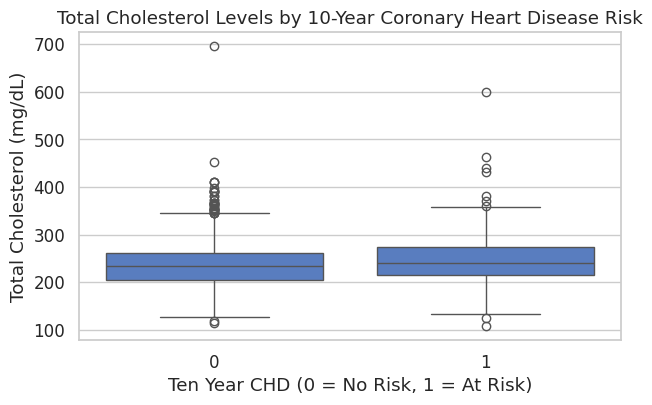

In [140]:
# Chart - 22 visualization code


# ============================================================
# 📊 Bivariate Analysis – Chart 6
# Visualizing the relationship between total cholesterol and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare total cholesterol levels across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='totChol',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Total Cholesterol Levels by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent total cholesterol values
plt.ylabel('Total Cholesterol (mg/dL)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Total cholesterol (totChol) is a continuous biochemical variable and one of the primary clinical indicators used to assess cardiovascular health.

* A box plot is chosen because it allows comparison of the distribution, median, variability, and outliers of cholesterol levels across individuals with and without 10-year coronary heart disease risk.

* This visualization helps evaluate whether elevated cholesterol levels are associated with increased CHD risk.

###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) show a slightly higher median total cholesterol level compared to the non-risk group.

* The distribution for the at-risk group is shifted modestly toward higher cholesterol values.

* Both groups exhibit several high-value outliers, indicating individuals with very high cholesterol levels in both risk categories.

* There is substantial overlap between the two distributions, suggesting cholesterol alone does not clearly separate CHD risk groups.

* Overall, total cholesterol shows a weak to moderate positive association with 10-year coronary heart disease risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The insight reinforces the importance of cholesterol monitoring and lipid management in cardiovascular risk reduction.

* Including total cholesterol in predictive models can improve performance when combined with age, blood pressure, glucose, and lifestyle factors.

* Healthcare systems can use this information to promote preventive care such as dietary changes and lipid-lowering therapies.


**Potential Negative Impact:**

* The large overlap between the two groups reduces cholesterol’s standalone predictive power.

* Presence of extreme outliers may affect model training if not handled carefully.

* Over-reliance on total cholesterol without considering HDL, LDL, or other lipid markers may oversimplify risk assessment.

**Conclusion :**

* The chart indicates that higher total cholesterol levels are associated with increased 10-year coronary heart disease risk, though the relationship is moderate.

* Total cholesterol is most effective as a predictive feature when used in combination with other clinical and lifestyle variables.

##### Chart 23 - Coronary Heart Disease Risk by heart rate

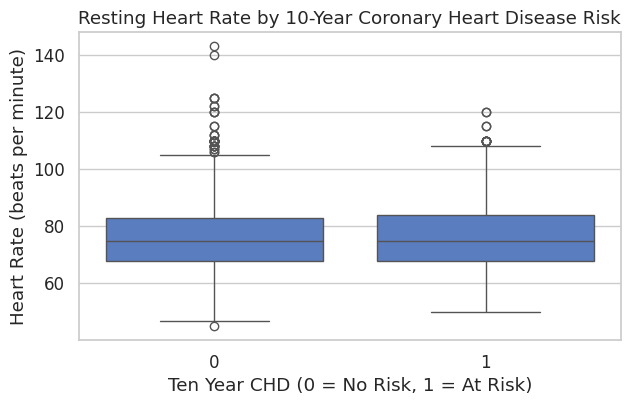

In [141]:
# Chart - 23 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 7
# Visualizing the relationship between heart rate and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare heart rate across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='heartRate',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Resting Heart Rate by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent resting heart rate values
plt.ylabel('Heart Rate (beats per minute)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Resting heart rate is a continuous physiological variable that reflects cardiovascular fitness and autonomic nervous system activity.

* A box plot is chosen because it allows comparison of the distribution, median, spread, and outliers of heart rate between individuals who are at risk and not at risk of developing coronary heart disease within 10 years.

* This chart helps assess whether resting heart rate differs meaningfully between CHD risk groups.

###### 2. What is/are the insight(s) found from the chart?

* The median heart rate for individuals at risk (TenYearCHD = 1) is very similar to that of individuals not at risk (TenYearCHD = 0).

* The overall distributions of heart rate for both groups overlap heavily, indicating minimal separation.

* Both groups show several high-value outliers, representing individuals with unusually elevated resting heart rates.

* The spread (IQR) is comparable across both categories, suggesting similar variability.

* This indicates that resting heart rate shows a weak or negligible direct association with 10-year coronary heart disease risk in this dataset.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight prevents overemphasis on heart rate as a primary risk factor in predictive modeling.

* Heart rate can still contribute value when combined with other variables such as blood pressure, age, and glucose.

* Healthcare providers can interpret elevated heart rate as a general health indicator rather than a standalone CHD predictor.


**Potential Negative Impact:**

* Including heart rate without proper feature evaluation may add noise to the model.

* Its weak discriminatory power may slightly reduce model efficiency if not weighted appropriately.

* Overinterpreting heart rate could divert attention from stronger predictors.

**Conclusion :**

* The chart suggests that resting heart rate does not strongly differentiate individuals at risk of coronary heart disease from those not at risk.

* While it remains clinically relevant, heart rate is best used as a supporting feature rather than a dominant predictor in CHD risk models.

##### Chart 24 - Coronary Heart Disease Risk by Cigarettes per day

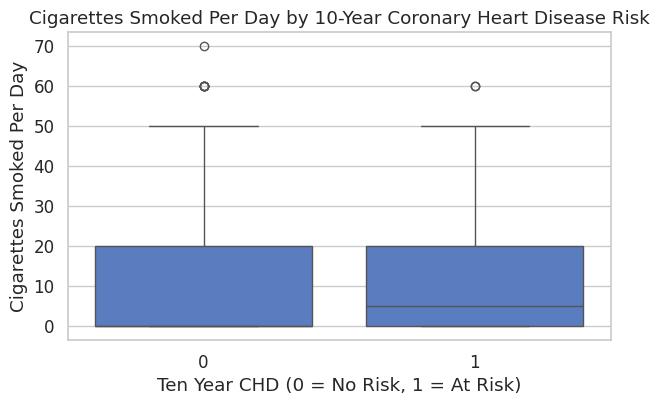

In [142]:
# Chart - 24 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 8
# Visualizing the relationship between cigarettes per day and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare cigarettes smoked per day across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='cigsPerDay',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Cigarettes Smoked Per Day by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent number of cigarettes smoked per day
plt.ylabel('Cigarettes Smoked Per Day')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* cigsPerDay is a continuous numerical variable that directly quantifies smoking intensity, which is a well-established lifestyle risk factor for coronary heart disease.

* A box plot is chosen to compare the distribution, median, spread, and outliers of daily cigarette consumption between individuals who are at risk and not at risk of developing CHD within 10 years.

* This chart helps assess whether heavier smoking is associated with higher CHD risk.

###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) show a higher median number of cigarettes smoked per day compared to the non-risk group.

* The distribution for the at-risk group is shifted toward higher cigarette consumption, indicating heavier smoking behavior.

* Both groups show many zero values, reflecting a large proportion of non-smokers.

* The at-risk group contains more extreme high-value outliers, representing heavy smokers.

* The overall spread is wider for the at-risk group, suggesting greater variability in smoking intensity.

* This indicates a positive association between cigarette consumption and 10-year CHD risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The insight strongly supports smoking as a key modifiable risk factor for coronary heart disease.

* Predictive models can leverage cigsPerDay to significantly improve risk stratification.

* Healthcare organizations can design targeted smoking cessation programs to reduce long-term cardiovascular risk and healthcare costs.


**Potential Negative Impact:**

* The large number of zero values may skew the distribution and require careful preprocessing.
Self-reported smoking data may contain reporting bias.

* If smoking behavior changes over time, static measurements may not fully capture risk.


**Conclusion :**

* The chart clearly shows that higher cigarette consumption per day is associated with increased 10-year coronary heart disease risk.

* Smoking intensity emerges as one of the most impactful lifestyle factors and is a strong candidate feature for predictive modeling.

##### Chart 25 - Coronary Heart Disease Risk by Sex

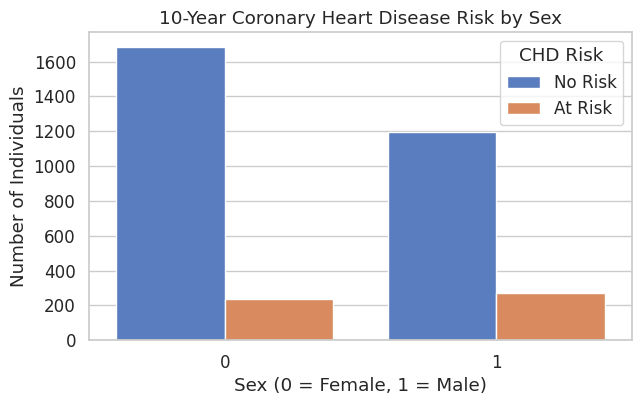

In [143]:
#Chart - 25 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 9
# Visualizing the relationship between sex and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a countplot to compare CHD risk across sex categories
ax = sns.countplot(
    x='sex',
    hue='TenYearCHD',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('10-Year Coronary Heart Disease Risk by Sex')

# labeling the x-axis to represent sex categories
plt.xlabel('Sex (0 = Female, 1 = Male)')

# labeling the y-axis to represent number of individuals
plt.ylabel('Number of Individuals')

# updating legend labels to be more interpretable
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['No Risk', 'At Risk'],
    title='CHD Risk'
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Sex is a categorical demographic variable, and TenYearCHD is a binary target variable.

* A count plot with hue is chosen because it allows direct comparison of the number of individuals at risk and not at risk across different sex categories.

* This chart is essential to understand whether gender-based differences exist in coronary heart disease risk.

###### 2. What is/are the insight(s) found from the chart?

* Both males and females have a larger number of individuals in the “No Risk” category, indicating that most individuals are not at immediate CHD risk.

* Males show a noticeably higher count of individuals in the “At Risk” category compared to females.

* Although females are more numerous overall in the dataset, the proportion of at-risk individuals is higher among males.

* This suggests that male individuals are more susceptible to 10-year coronary heart disease risk in this dataset.

* The difference is visually clear and consistent across categories.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight enables gender-aware cardiovascular risk assessment, allowing healthcare providers to focus more on early screening and prevention among male populations.

* Predictive models can leverage sex as an important categorical feature to improve CHD risk prediction accuracy.

* Public health strategies can be designed with targeted interventions for higher-risk male populations, optimizing resource allocation.


**Potential Negative Impact:**

* Sex is a non-modifiable factor, so it cannot be directly acted upon for risk reduction.

* Overemphasizing sex alone may lead to underestimation of risk in females who have strong clinical or lifestyle risk factors.

* If not combined with other variables, it could introduce demographic bias in predictions.

**Conclusion :**

* The chart clearly indicates that males have a higher likelihood of being at risk for coronary heart disease compared to females.

* While sex itself cannot be modified, it plays a crucial role in risk stratification when combined with clinical and lifestyle factors.

##### Chart 26 - Coronary Heart Disease Risk by Smoking Status


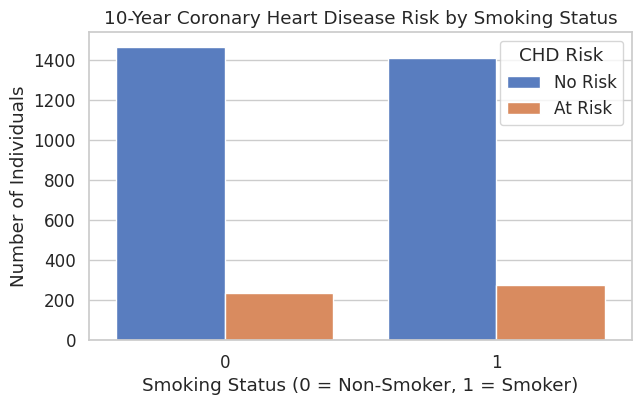

In [144]:
# Chart - 26 visualization code


# ============================================================
# 📊 Bivariate Analysis – Chart 10
# Visualizing the relationship between smoking status and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a countplot to compare CHD risk across smoking status categories
ax = sns.countplot(
    x='is_smoking',
    hue='TenYearCHD',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('10-Year Coronary Heart Disease Risk by Smoking Status')

# labeling the x-axis to represent smoking status categories
plt.xlabel('Smoking Status (0 = Non-Smoker, 1 = Smoker)')

# labeling the y-axis to represent number of individuals
plt.ylabel('Number of Individuals')

# updating legend labels to be more interpretable
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['No Risk', 'At Risk'],
    title='CHD Risk'
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Smoking status is a categorical lifestyle variable, and TenYearCHD is the binary target variable.

* A count plot with hue is chosen because it clearly compares the number of individuals at risk and not at risk across smoking and non-smoking groups.

* This chart helps assess whether smoking behavior has a visible association with long-term coronary heart disease risk.

###### 2. What is/are the insight(s) found from the chart?

* In both smoking and non-smoking groups, the majority of individuals fall under the “No Risk” category.

* The number of individuals in the “At Risk” category is higher among smokers compared to non-smokers.

* Although non-smokers are more numerous overall, the proportion of at-risk individuals is visibly greater among smokers.

* This indicates that smoking status is associated with an elevated likelihood of 10-year CHD risk.
The pattern is consistent and clearly distinguishable across categories.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight reinforces smoking as a major modifiable risk factor for coronary heart disease.

* Predictive models can use smoking status as a strong categorical feature to improve risk prediction accuracy.

* Healthcare organizations can design targeted smoking cessation programs, which can significantly reduce future cardiovascular events and healthcare costs.

**Potential Negative Impact:**

* Smoking status is often self-reported and may suffer from reporting bias.

* Binary smoking status does not capture smoking intensity or duration, which may limit predictive granularity.

* Overreliance on smoking status alone may overlook non-smokers with high clinical risk due to other factors.


**Conclusion :**

* The chart clearly shows that smokers have a higher proportion of individuals at risk of developing coronary heart disease within 10 years compared to non-smokers.

* Smoking emerges as one of the most impactful lifestyle-related risk factors and is a critical feature for cardiovascular risk prediction models.

##### Chart 27 - Coronary Heart Disease Risk by Diabetes Status

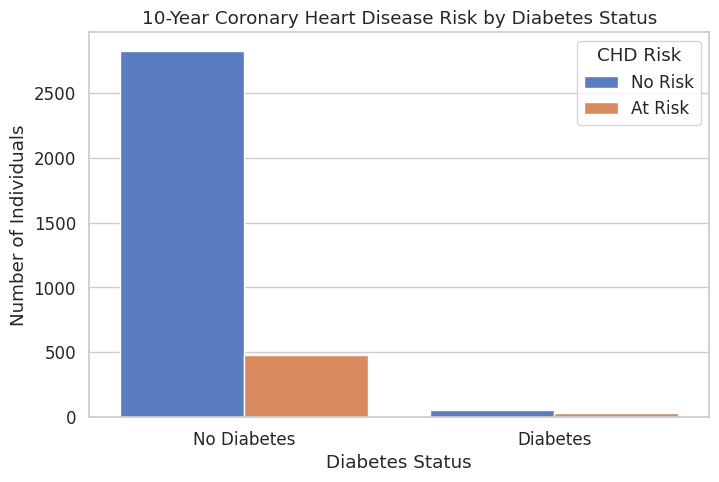

In [145]:
# Chart - 27 visualization code


# ============================================================
# 📊 Bivariate Analysis - Chart 11
# Visualizing the relationship between prevalent Diabetes Status and 10-year CHD risk
# ============================================================



# Setting the figure size for better readability
plt.figure(figsize=(8, 5))

# Creating a count plot to compare diabetes status with 10-year CHD risk
# Diabetes is used as the categorical variable
# TenYearCHD is used as the target variable
sns.countplot(
    data=df,
    x='diabetes',
    hue='TenYearCHD'
)

# Updating x-axis tick labels to make them more interpretable
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])

# Adding labels and title to clearly explain the chart
plt.xlabel('Diabetes Status')
plt.ylabel('Number of Individuals')
plt.title('10-Year Coronary Heart Disease Risk by Diabetes Status')

# Updating legend labels to replace 0 and 1 with meaningful categories
plt.legend(title='CHD Risk', labels=['No Risk', 'At Risk'])

# Displaying the plot
plt.show()

###### 1. Why did you pick the specific chart?

* Diabetes is a critical clinical condition known to influence cardiovascular health, and TenYearCHD is the target variable indicating long-term coronary heart disease risk.

* A count plot with hue is chosen because both diabetes status and the target variable are categorical, and this visualization allows a clear comparison of individuals at risk and not at risk across diabetic and non-diabetic groups.

* This chart helps in understanding whether the presence of diabetes has a visible association with increased 10-year CHD risk.

###### 2. What is/are the insight(s) found from the chart?

* The dataset contains a large majority of non-diabetic individuals and a very small proportion of diabetic individuals.

* Among non-diabetic individuals, most fall under the “No Risk” category, with a smaller but noticeable number classified as “At Risk.”

* Among diabetic individuals, although the total count is low, the proportion of individuals in the “At Risk” category is relatively high compared to non-diabetics.

* This indicates that diabetes is associated with a higher likelihood of developing coronary heart disease within 10 years.

* The difference in risk distribution suggests diabetes acts as a strong amplifying risk factor, even if its prevalence in the dataset is limited.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Diabetes emerges as a high-impact clinical predictor for coronary heart disease risk.

* Including diabetes status in predictive models can significantly improve risk stratification and early detection.

* Healthcare providers can prioritize preventive care, monitoring, and lifestyle interventions for diabetic patients to reduce long-term cardiovascular complications.

* From a business and healthcare analytics perspective, early identification can lead to reduced treatment costs and improved patient outcomes.


**Potential Negative Impact:**

* The diabetic class is highly imbalanced, which may cause bias in predictive models if not handled carefully.

* Diabetes is represented as a binary variable, which does not capture disease severity, duration, or glucose control levels.

* Overemphasis on diabetes alone could underrepresent cardiovascular risk in non-diabetic individuals with other strong risk factors.


**Conclusion :**

* The chart clearly demonstrates that individuals with diabetes have a higher proportion of 10-year coronary heart disease risk compared to non-diabetic individuals.

* Despite its low frequency in the dataset, diabetes shows a strong association with elevated CHD risk, making it a crucial clinical feature for cardiovascular risk prediction models.

##### Chart 28 - Coronary Heart Disease Risk by Hypertension Status

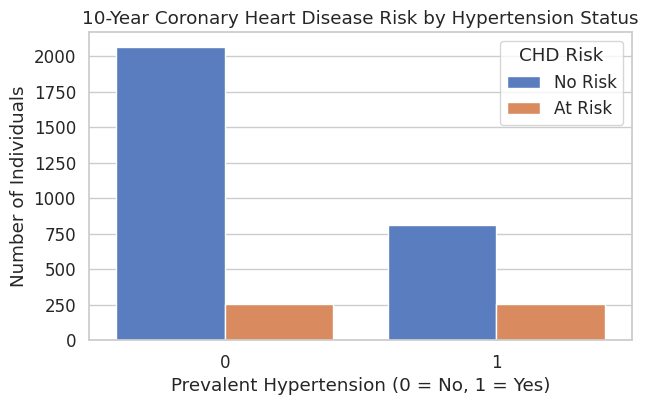

In [146]:
# Chart - 28 visualization code

# ============================================================
# 📊 Bivariate Analysis - Chart 12
# Visualizing the relationship between prevalent hypertension and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a countplot to compare CHD risk across hypertension status
ax = sns.countplot(
    x='prevalentHyp',
    hue='TenYearCHD',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('10-Year Coronary Heart Disease Risk by Hypertension Status')

# labeling the x-axis to represent hypertension status categories
plt.xlabel('Prevalent Hypertension (0 = No, 1 = Yes)')

# labeling the y-axis to represent number of individuals
plt.ylabel('Number of Individuals')

# updating legend labels to be more interpretable
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['No Risk', 'At Risk'],
    title='CHD Risk'
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Prevalent hypertension is a clinically significant binary variable that directly reflects long-term blood pressure conditions.

* TenYearCHD is the target variable representing future coronary heart disease risk.

* A count plot with hue is selected because:

  * Both variables are categorical

  * It allows a clear comparison of CHD risk distribution between individuals with and without hypertension

  * It helps evaluate whether hypertension status is associated with increased CHD risk

* This visualization is ideal for understanding the impact of an existing medical condition on future cardiovascular outcomes.

###### 2. What is/are the insight(s) found from the chart?

* Individuals without prevalent hypertension (0) form the largest group overall.

* Among non-hypertensive individuals, the majority fall under the “No Risk” category, with relatively fewer at-risk cases.

* Individuals with prevalent hypertension (1) show a much higher proportion of “At Risk” cases compared to their group size.

* Although fewer individuals have hypertension overall, the count of at-risk individuals is nearly comparable to the non-hypertensive group.

* This indicates that the probability of developing CHD is significantly higher among individuals with hypertension.

* The visual separation between risk categories is strong and consistent.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Hypertension emerges as a strong predictive feature for coronary heart disease risk.

* Early identification and management of hypertensive patients can significantly reduce long-term cardiovascular events.

* Predictive models can leverage this variable to improve risk stratification accuracy.

* Healthcare systems can prioritize preventive interventions for hypertensive populations, reducing treatment costs and hospitalizations.


**Potential Negative Impact:**

* Hypertension is recorded as a binary variable and does not capture severity or duration.

* Some individuals may be on medication that controls BP, which may mask true physiological risk.

* Over-reliance on hypertension alone may ignore normotensive individuals with high risk due to other factors.

* Overall, the positive impact far outweighs limitations.


**Conclusion :**

* The bivariate analysis clearly demonstrates that individuals with prevalent hypertension have a substantially higher likelihood of developing coronary heart disease within 10 years.

* Prevalent hypertension is a critical clinical risk factor and should be treated as a high-importance feature in predictive modeling.

##### Chart 29 -  Coronary Heart Disease Risk by BP Medication Status

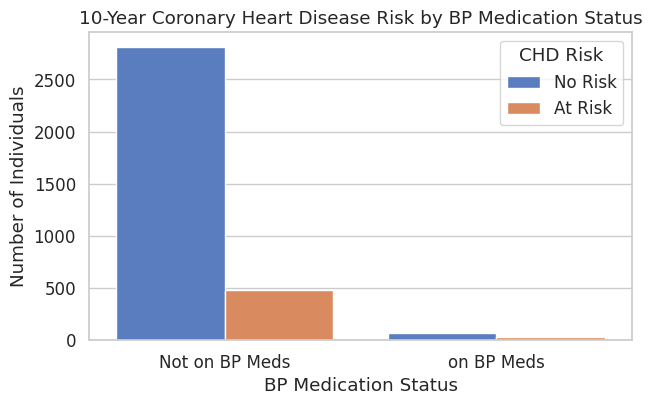

In [147]:
# Chart - 29 visualization code

# ============================================================
# 📊 Bivariate Analysis - Chart 13
# Visualizing the relationship between BP Medications and 10-year CHD risk
# ============================================================


# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a countplot to compare CHD risk across BP medication status
ax = sns.countplot(
    x='BPMeds',
    hue='TenYearCHD',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('10-Year Coronary Heart Disease Risk by BP Medication Status')

# labeling the x-axis to represent BP medication categories
plt.xlabel('BP Medication Status')

# Updating x-axis tick labels to make them more interpretable
plt.xticks([0, 1], ['Not on BP Meds', 'on BP Meds'])

# labeling the y-axis to represent number of individuals
plt.ylabel('Number of Individuals')

# extracting legend handles and labels
handles, labels = ax.get_legend_handles_labels()

# updating legend labels to be more interpretable
ax.legend(
    handles,
    ['No Risk', 'At Risk'],
    title='CHD Risk'
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* BP medication status (BPMeds) is a categorical clinical variable that indicates whether an individual is already under treatment for hypertension.

* Since TenYearCHD is the binary target variable, a count plot with hue is the most appropriate visualization to compare CHD risk distribution between individuals on BP medication and those not on BP medication.

* This chart helps evaluate whether being on BP medication is associated with future coronary heart disease risk.

###### 2. What is/are the insight(s) found from the chart?

* The majority of individuals are not on BP medications, and most of them fall under the No Risk category.

* Individuals who are on BP medications form a much smaller subset of the dataset.

* Among individuals on BP medications, the proportion of “At Risk” cases is noticeably higher compared to those not on BP medications.

* This suggests that people on BP medications already belong to a clinically high-risk group, which aligns with medical expectations.

* BP medication status appears to be a strong indicator of underlying cardiovascular risk rather than a protective factor.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* BP medication status can act as a high-signal clinical feature for CHD risk prediction models.

* Healthcare systems can prioritize individuals on BP medications for early cardiovascular screening and monitoring.

* Predictive models incorporating this variable can improve risk stratification accuracy, leading to better preventive interventions and reduced long-term healthcare costs.

**Potential Negative Impact:**

* BP medication usage may introduce confounding bias, as it reflects existing hypertension rather than causing CHD directly.

* The small number of individuals on BP medications may lead to class imbalance issues during modeling.

* Overinterpreting BP medication as a causal factor may lead to misleading conclusions without considering blood pressure levels and duration of treatment.


**Conclusion :**

* The chart clearly indicates that individuals on BP medications have a higher proportion of 10-year CHD risk compared to those not on medication.

* BP medication status effectively captures pre-existing cardiovascular vulnerability and is a valuable feature for predictive modeling, provided its limitations are carefully handled.

##### Chart 30 - Relationship between Prevalent Stroke and 10-year CHD risk

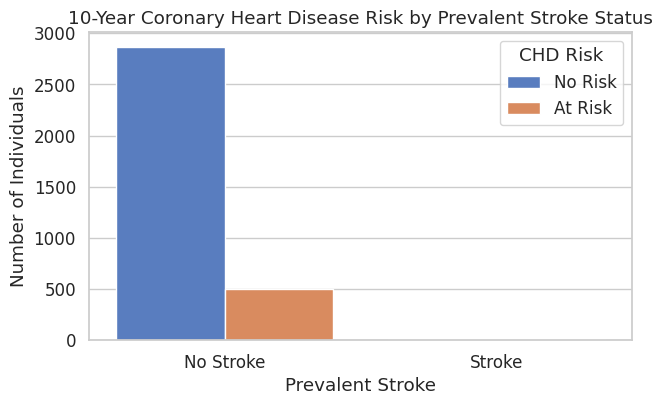

In [148]:
# Chart - 30 visualization code

# ============================================================
# 📊 Bivariate Analysis - Chart 14
# Visualizing the relationship between Prevalent Stroke and 10-year CHD risk
# ============================================================


# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a countplot to compare CHD risk across prevalent stroke categories
ax = sns.countplot(
    x='prevalentStroke',
    hue='TenYearCHD',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('10-Year Coronary Heart Disease Risk by Prevalent Stroke Status')

# labeling the x-axis to represent stroke status
plt.xlabel('Prevalent Stroke')

# Updating x-axis tick labels to make them more interpretable
plt.xticks([0, 1], ['No Stroke', 'Stroke'])

# labeling the y-axis to represent number of individuals
plt.ylabel('Number of Individuals')

# updating legend labels to be more interpretable
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['No Risk', 'At Risk'],
    title='CHD Risk'
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Prevalent stroke is a binary clinical history variable, and TenYearCHD is the binary target variable.

* A count plot with hue is selected because it allows direct comparison of the number of individuals at risk and not at risk across stroke-history categories.

* This visualization helps evaluate whether a prior stroke event has a visible association with future coronary heart disease risk.

###### 2. What is/are the insight(s) found from the chart?

* The vast majority of individuals do not have a history of stroke.

* Almost all individuals with a prior stroke are very few in number, indicating a highly imbalanced distribution for the prevalentStroke feature.

* Among individuals without a prior stroke, there is a clear presence of both “No Risk” and “At Risk” groups.

* Due to the extremely low count of individuals with prior stroke, no strong visual pattern can be confidently established between prevalent stroke and 10-year CHD risk from this dataset alone.

* The chart suggests that prevalent stroke is a rare event in the dataset rather than a dominant predictor.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The analysis highlights that prior stroke cases are rare, which helps in understanding dataset limitations.

* This insight prevents overestimating the importance of the prevalentStroke feature during model training.

* Healthcare models can still include this feature as a supporting clinical indicator rather than a primary driver.

**Potential Negative Impact:**

* The extreme class imbalance may reduce the predictive contribution of this feature.

* Models may struggle to learn meaningful patterns from such sparse data.

* Overweighting this variable could introduce noise instead of improving prediction accuracy.


**Conclusion :**

* The bivariate analysis shows that prevalent stroke cases are extremely limited in the dataset, making it difficult to establish a strong relationship with 10-year coronary heart disease risk.

* While clinically important, this feature should be treated cautiously and used as a secondary predictor in the modeling phase.

##### Chart 31 - Relationship between Systolic BP vs Diastolic BP

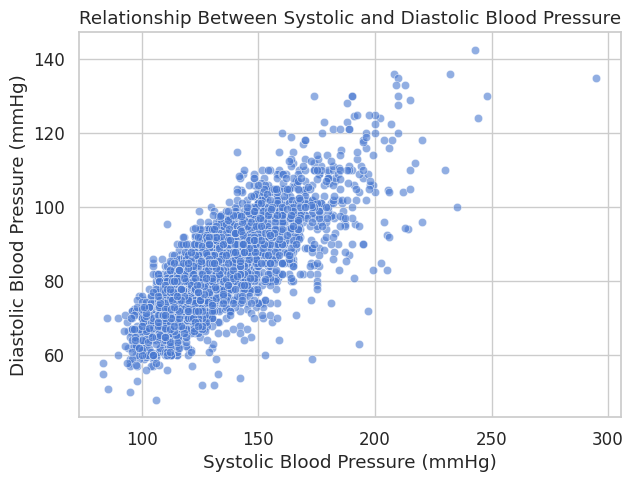

In [149]:
# Chart - 31 visualization code


# ============================================================
# 📊 Bivariate Analysis - Chart 15
# Visualizing the relationship between Systolic BP vs Diastolic BP
# ============================================================


# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 5))

# plotting a scatter plot to visualize the relationship between systolic and diastolic blood pressure
sns.scatterplot(
    x='sysBP',
    y='diaBP',
    data=df_wrangle,
    alpha=0.6
)

# setting the title to describe the relationship being visualized
plt.title('Relationship Between Systolic and Diastolic Blood Pressure')

# labeling the x-axis to represent systolic blood pressure values
plt.xlabel('Systolic Blood Pressure (mmHg)')

# labeling the y-axis to represent diastolic blood pressure values
plt.ylabel('Diastolic Blood Pressure (mmHg)')

# displaying the final plot
plt.show()


###### 1. Why did you pick the specific chart?

Systolic and diastolic blood pressure are two clinically related physiological measurements.
This scatter plot is chosen to understand:

* The relationship and dependency between systolic and diastolic blood pressure

* Whether both variables move together or independently

* The presence of multicollinearity, which is critical before building machine learning models

Understanding this relationship is essential because highly correlated features can impact model stability and interpretability.

###### 2. What is/are the insight(s) found from the chart?

* There is a clear positive linear relationship between systolic and diastolic blood pressure.

* As systolic blood pressure increases, diastolic blood pressure also increases consistently.

* Most data points are densely clustered, indicating a strong and stable association between the two variables.

* A few scattered points at very high systolic values suggest the presence of outliers, which may represent severe hypertension cases or measurement extremes.

* The overall pattern confirms that these two variables are not independent of each other.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The strong correlation helps validate the clinical reliability of the dataset.

* This insight allows data scientists to make informed decisions during feature selection, such as:

* Keeping both variables for clinical completeness, or

* Removing one to reduce multicollinearity in linear models.

* Healthcare providers can use this relationship to flag individuals at higher cardiovascular risk when either pressure is elevated.

* Predictive models can be optimized by understanding how blood pressure components jointly contribute to CHD risk.

**Potential Negative Impact:**

* Including both highly correlated variables without adjustment may lead to model instability, especially in linear or distance-based algorithms.

* Multicollinearity can reduce interpretability of model coefficients and inflate variance.

* Outliers, if not handled carefully, may disproportionately influence model predictions.


**Conclusion :**

* The analysis shows a strong positive relationship between systolic and diastolic blood pressure, confirming expected cardiovascular physiology.

* This insight is crucial for feature selection and model design, as it highlights potential multicollinearity while reinforcing the importance of blood pressure as a core predictor of heart disease risk.

##### Chart 32 - Relationship between Age and Systolic Blood Pressure

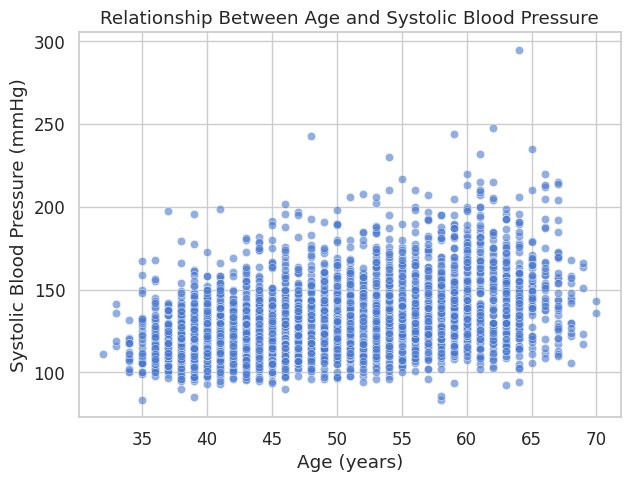

In [150]:
# Chart - 32 visualization code

# ============================================================
# 📊 Bivariate Analysis - Chart 16
# Visualizing the relationship between Age and Systolic Blood Pressure
# ============================================================


# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 5))

# plotting a scatter plot to visualize the relationship between age and systolic blood pressure
sns.scatterplot(
    x='age',
    y='sysBP',
    data=df_wrangle,
    alpha=0.6
)

# setting the title to describe the relationship being visualized
plt.title('Relationship Between Age and Systolic Blood Pressure')

# labeling the x-axis to represent age in years
plt.xlabel('Age (years)')

# labeling the y-axis to represent systolic blood pressure values
plt.ylabel('Systolic Blood Pressure (mmHg)')

# displaying the final plot
plt.show()


###### 1. Why did you pick the specific chart?

* Age is a fundamental demographic variable, and systolic blood pressure is a key clinical risk factor for cardiovascular disease.
* This chart is chosen to understand:

  * How systolic blood pressure varies with increasing age

  * Whether age contributes indirectly to CHD risk through rising blood pressure

  * The presence of any visible trend or abnormal patterns across age groups

* A scatter plot is appropriate because it reveals both **trend and variability** across a continuous range of values.

###### 2. What is/are the insight(s) found from the chart?

* There is a **clear upward trend** indicating that systolic blood pressure generally increases with age.

* Younger individuals mostly cluster around lower systolic blood pressure values.

* As age increases, the **spread of systolic blood pressure widens**, showing greater variability among older individuals.

* Several **high systolic blood pressure outliers** are visible in older age groups, indicating higher prevalence of severe hypertension.

* This pattern suggests that age is an important indirect contributor to cardiovascular risk through blood pressure elevation.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight helps identify older age groups as priority segments for blood pressure monitoring and early intervention.

* Predictive models can leverage age as a strong explanatory variable influencing systolic blood pressure and CHD risk.

* Healthcare organizations can design age-specific screening and preventive strategies to reduce long-term cardiovascular events.

* The observed trend supports using age-related thresholds in risk stratification systems.


**Potential Negative Impact:**

* Age is a non-modifiable risk factor, limiting direct intervention strategies.

* High variability in systolic blood pressure among older individuals may introduce noise into predictive models.

* Overemphasis on age may lead to underestimation of risk in younger individuals with abnormal blood pressure.

**Conclusion :**

* The chart demonstrates a clear positive relationship between age and systolic blood pressure, confirming expected cardiovascular aging patterns.

* This insight reinforces the importance of age as a foundational variable in heart disease risk prediction and highlights the need for age-adjusted clinical interventions.

##### Chart 33 - Relationship between Body Mass Index and blood glucose levels

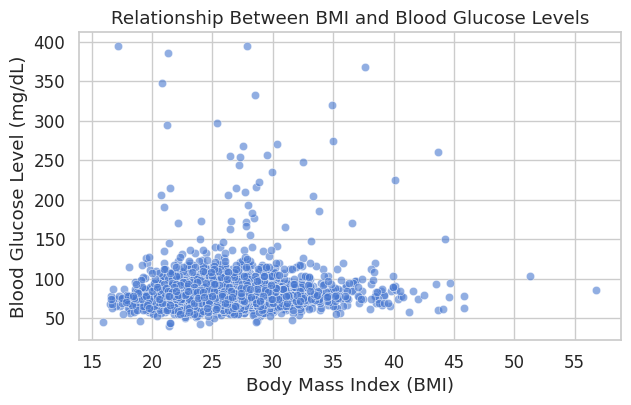

In [151]:
# Chart - 33 visualization code


# ============================================================
# 📊 Bivariate Analysis - Chart 17
# Visualizing the relationship between Body Mass Index and blood glucose levels
# ============================================================


# creating a new figure to control the size of the scatter plot
plt.figure(figsize=(7, 4))

# plotting a scatter plot to examine the relationship between BMI and glucose
sns.scatterplot(
    x='BMI',
    y='glucose',
    data=df_wrangle,
    alpha=0.6
)

# setting the title to describe the relationship being visualized
plt.title('Relationship Between BMI and Blood Glucose Levels')

# labeling the x-axis to represent Body Mass Index
plt.xlabel('Body Mass Index (BMI)')

# labeling the y-axis to represent blood glucose levels
plt.ylabel('Blood Glucose Level (mg/dL)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Body Mass Index (BMI) and blood glucose are both continuous clinical variables closely linked to metabolic health.

* A scatter plot is selected because it is the most appropriate visualization to:

  * Examine the relationship and trend between two numerical variables

  * Detect patterns, clusters, and outliers

  * Assess whether increasing BMI is associated with higher glucose levels, which is clinically relevant for diabetes and cardiovascular risk analysis

* This chart helps understand whether BMI contributes indirectly to CHD risk through elevated glucose levels.

###### 2. What is/are the insight(s) found from the chart?

* The majority of individuals are clustered in the BMI range of 20–35 with glucose levels mostly between 60–120 mg/dL

* There is no strong linear relationship between BMI and glucose across the full dataset.

* However, individuals with very high glucose levels (200+ mg/dL) tend to appear more frequently in the moderate to high BMI range.

* Several extreme glucose outliers are visible across different BMI values, indicating possible diabetic cases.

* BMI alone does not fully explain glucose variation, suggesting the influence of additional clinical or lifestyle factors.

* Overall, the relationship appears weak to moderate, with noticeable variability.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The chart confirms that BMI alone is insufficient to predict glucose levels, encouraging the use of multivariate modeling

* It highlights the importance of combining BMI with variables such as age, diabetes status, blood pressure, and smoking

* Healthcare providers can avoid oversimplified assumptions and adopt personalized risk assessments
Feature engineering opportunities arise (e.g., BMI + glucose interaction terms)

**Potential Negative Impact:**

* High variability may reduce the predictive strength of BMI if used in isolation

* Outliers may skew models if not properly handled during preprocessing

* Overemphasis on BMI may lead to underestimating risk in normal-BMI individuals with high glucose

**Conclusion :**

* The analysis shows that while higher BMI is occasionally associated with elevated glucose levels, the relationship is not strongly linear.

* Glucose variability exists across all BMI ranges, indicating that BMI alone cannot reliably predict blood glucose levels.

* This reinforces the need for multivariate analysis and supports glucose as an independent and critical feature in cardiovascular risk prediction.

##### Chart 34 - Relationship Between Body Mass Index (BMI) and Systolic Blood Pressure

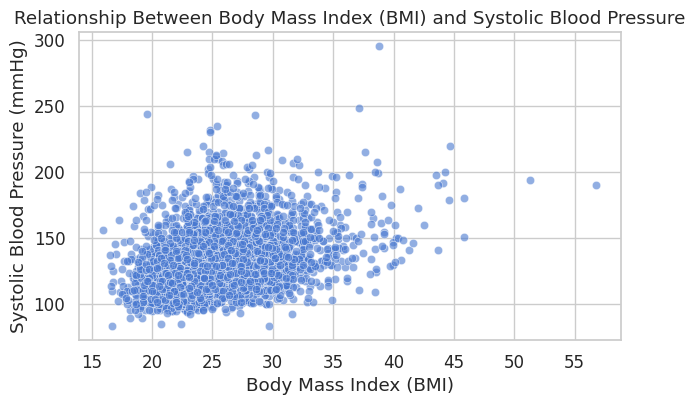

In [152]:
# Chart - 34 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 18
# Visualizing the relationship between BMI and systolic BP
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a scatter plot to analyze the relationship between BMI and systolic blood pressure
sns.scatterplot(
    x='BMI',
    y='sysBP',
    data=df_wrangle,
    alpha=0.6
)

# setting the title to clearly describe the relationship being visualized
plt.title('Relationship Between Body Mass Index (BMI) and Systolic Blood Pressure')

# labeling the x-axis to represent Body Mass Index values
plt.xlabel('Body Mass Index (BMI)')

# labeling the y-axis to represent systolic blood pressure values
plt.ylabel('Systolic Blood Pressure (mmHg)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Body Mass Index (BMI) and systolic blood pressure are both critical cardiovascular health indicators.

* This chart is chosen to examine whether increased body weight is associated with higher systolic blood pressure levels.

* A scatter plot is appropriate here because it helps visualize patterns, trends, and variability between two continuous variables and allows identification of correlation and potential outliers.

###### 2. What is/are the insight(s) found from the chart?

* There is a positive relationship between BMI and systolic blood pressure.

* As BMI increases, systolic blood pressure values tend to increase gradually.

* Individuals with higher BMI values show a wider spread and higher upper range of systolic BP, indicating increased variability in blood pressure among overweight and obese individuals.

* Most individuals cluster around BMI values of 20-30, with systolic BP mostly between 110-160 mmHg.

* Extreme systolic BP values are more frequently observed at higher BMI levels, highlighting elevated cardiovascular strain.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The observed relationship confirms BMI as an important predictor feature for systolic blood pressure and cardiovascular risk.

* Healthcare providers can use this insight to emphasize weight management programs to control blood pressure and reduce long-term CHD risk.

* Predictive models can benefit from including BMI to improve accuracy in identifying high-risk individuals.

**Potential Negative Impact:**

* The relationship is not perfectly linear, suggesting BMI alone cannot fully explain blood pressure variations.

* Individuals with normal BMI but high systolic BP may be overlooked if BMI is overemphasized.

* Lifestyle, genetics, and medication factors may confound the relationship and should be jointly considered.

**Conclusion :**

* The chart demonstrates a clear positive association between BMI and systolic blood pressure.

* Higher BMI is linked with elevated systolic BP levels, reinforcing BMI as a significant cardiovascular risk factor and an important feature for downstream predictive modeling.

##### Chart 35 - Blood Glucose Levels by Diabetes Status

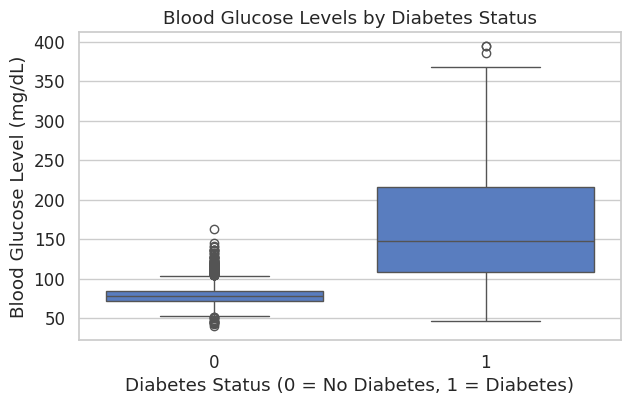

In [153]:
# Chart - 35 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 19
# Visualizing the relationship between diabetes status and glucose levels
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare glucose levels across diabetes status
sns.boxplot(
    x='diabetes',
    y='glucose',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Blood Glucose Levels by Diabetes Status')

# labeling the x-axis to represent diabetes categories
plt.xlabel('Diabetes Status (0 = No Diabetes, 1 = Diabetes)')

# labeling the y-axis to represent glucose levels
plt.ylabel('Blood Glucose Level (mg/dL)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Diabetes status is a binary clinical variable, while glucose is a continuous numerical variable and also a core diagnostic indicator for diabetes.

* A box plot is chosen because it clearly compares:

  * Central tendency (median),

  * Spread (IQR),

  * Presence of outliers

  across diabetic and non-diabetic groups.

* This visualization helps validate whether the diabetes label aligns logically with glucose distribution and checks the clinical consistency of the dataset.

###### 2. What is/are the insight(s) found from the chart?

* Individuals **without diabetes (0)** show glucose values tightly clustered around normal ranges (roughly 70–100 mg/dL).

* Individuals **with diabetes (1)** have a **significantly higher median glucose level.**

* The diabetic group exhibits:

  *  Much wider variability,

  * Several extreme high-value outliers,

  * A clear right-skewed distribution.

* There is a **strong separation** between the glucose distributions of diabetic and non-diabetic individuals, with minimal overlap in medians.

* This confirms that glucose is a **highly discriminative feature** with respect to diabetes status.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The clear distinction confirms data quality and labeling consistency, increasing trust in the dataset.

* Glucose emerges as a highly predictive numerical feature, which can significantly improve model performance.

* Healthcare providers can use glucose thresholds to identify high-risk patients early, reducing long-term treatment costs.

* This insight supports building rule-based alerts alongside ML models for preventive care.

**Potential Negative Impact:**

* Extreme glucose outliers may disproportionately influence models if not handled properly.

* Overreliance on glucose alone could mask risk in pre-diabetic individuals with borderline values.

* Clinical measurements can vary due to fasting/non-fasting conditions, which may introduce noise.


**Conclusion :**

* The chart clearly demonstrates that individuals diagnosed with diabetes have substantially higher and more variable blood glucose levels compared to non-diabetics.

* This strong separation validates glucose as one of the most powerful clinical indicators in cardiovascular and metabolic risk prediction and confirms its importance for downstream modeling.

##### Chart 36 - Impact of Smoking Intensity on Total Cholesterol

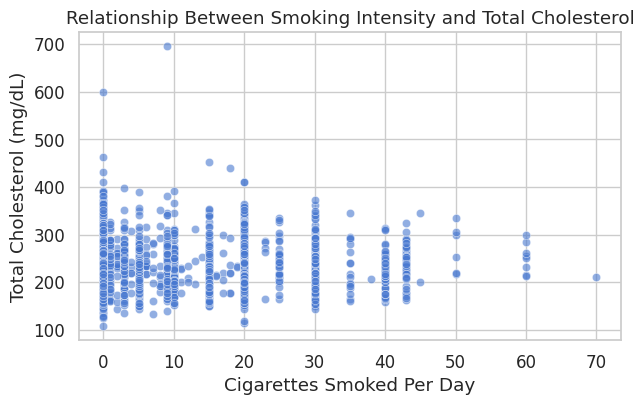

In [154]:
# Chart - 36 visualization code


# ============================================================
# 📊 Bivariate Analysis – Chart 20
# Visualizing the relationship between Smoking Intensity and Total Cholesterol
# ============================================================


# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a scatter plot to visualize the relationship between
# number of cigarettes smoked per day and total cholesterol level
sns.scatterplot(
    x='cigsPerDay',
    y='totChol',
    data=df_wrangle,
    alpha=0.6
)

# setting the title to describe the relationship being visualized
plt.title('Relationship Between Smoking Intensity and Total Cholesterol')

# labeling the x-axis to represent smoking intensity
plt.xlabel('Cigarettes Smoked Per Day')

# labeling the y-axis to represent total cholesterol levels
plt.ylabel('Total Cholesterol (mg/dL)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?


* Smoking intensity (cigsPerDay) is a continuous lifestyle variable, and total cholesterol (totChol) is a critical clinical biomarker for cardiovascular risk.

* A scatter plot is the most appropriate choice here because it allows us to:

  * Observe whether increasing smoking intensity is associated with higher cholesterol levels

  * Identify trends, clusters, and extreme outliers

  * Understand whether smoking affects cholesterol in a linear, non-linear, or inconsistent manner

* This chart helps evaluate whether smoking contributes indirectly to heart disease risk through cholesterol elevation.

###### 2. What is/are the insight(s) found from the chart?

* There is no strong linear relationship between cigarettes smoked per day and total cholesterol levels.

* Most individuals, regardless of smoking intensity, have cholesterol values clustered between 150–300 mg/dL.

* Heavy smokers (high cigsPerDay) do not consistently show higher cholesterol levels than light smokers or non-smokers.

* Several extreme cholesterol outliers are present even among non-smokers, indicating that factors other than smoking (such as diet, genetics, or metabolic conditions) significantly influence cholesterol.

* Smoking intensity alone does not appear to be a reliable predictor of total cholesterol levels.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight prevents incorrect assumptions that higher smoking intensity directly leads to higher cholesterol.

* It encourages multifactor modeling, where cholesterol is predicted using multiple features (BMI, age, glucose, hypertension) instead of smoking alone.

* Healthcare strategies can focus smoking cessation more on direct cardiovascular damage rather than cholesterol control alone.

* Helps improve feature selection by avoiding redundant or weakly correlated predictors.


**Potential Negative Impact:**

* Smoking intensity being weakly related to cholesterol may reduce its standalone predictive power in cholesterol-focused models.

* Smoking effects may be long-term or indirect, which cannot be captured fully in a single-time snapshot dataset.

* Relying solely on cross-sectional data may underrepresent cumulative smoking effects.


**Conclusion :**

* The chart indicates that smoking intensity does not have a strong direct relationship with total cholesterol levels.

* While smoking is a major cardiovascular risk factor, its impact on heart disease is likely mediated through mechanisms other than cholesterol elevation, such as inflammation, endothelial damage, and blood clot formation.

* This highlights the importance of multivariate analysis for accurate risk prediction.

##### Chart 37 - Relationship Between Age and Diastolic Blood Pressure

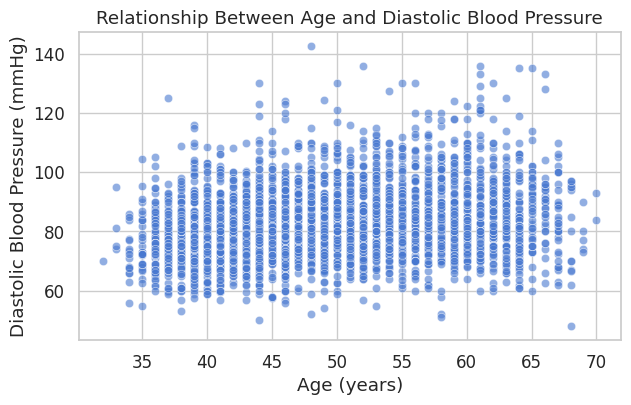

In [155]:
# Chart - 37 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 21
# Visualizing the relationship between Age and Diastolic Blood Pressure
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a scatter plot to analyze the relationship
sns.scatterplot(
    x='age',
    y='diaBP',
    data=df_wrangle,
    alpha=0.6
)

# setting the title
plt.title('Relationship Between Age and Diastolic Blood Pressure')

# labeling the x-axis
plt.xlabel('Age (years)')

# labeling the y-axis
plt.ylabel('Diastolic Blood Pressure (mmHg)')

# displaying the plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age is a fundamental non-modifiable risk factor, while diastolic blood pressure is a key clinical indicator related to cardiovascular health.

* This chart is chosen to understand how diastolic blood pressure varies across different age groups and whether aging shows any observable pattern or trend with respect to diastolic BP levels.

* A scatter plot is appropriate here because both variables are continuous, and it helps visualize dispersion, trends, and variability across age.

###### 2. What is/are the insight(s) found from the chart?

* Diastolic blood pressure values are largely concentrated between 60 mmHg and 100 mmHg across all age groups.

* There is a mild upward trend in diastolic BP from younger ages (early 30s) to middle age (around 50–55 years).

* After middle age, diastolic BP appears to plateau or slightly decline, with increased spread in older age groups.

* Variability in diastolic BP increases with age, indicating that older individuals show a wider range of BP values.

* A few high outliers are present across ages, suggesting cases of uncontrolled or severe hypertension.

* Overall, the relationship is non-linear and weak-to-moderate, rather than strongly linear.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The chart highlights that diastolic BP does not continuously increase with age, which supports clinical findings that systolic BP is often a stronger age-related predictor.

* This insight helps feature selection by indicating that age–diaBP interaction may be less predictive than age–sysBP.

* Healthcare providers can use this information to focus screening and intervention strategies differently across age groups.

**Potential Negative Impact:**

* Using diastolic BP alone as an age-related predictor may lead to weaker model performance.

* Ignoring variability and outliers may underestimate risk in specific subpopulations with abnormal BP patterns.


**Conclusion :**

* The relationship between age and diastolic blood pressure shows a mild increase up to middle age followed by stabilization, with increasing variability in older individuals.

* While age influences diastolic BP, the association is not strong or linear, indicating that diastolic BP should be considered alongside other clinical variables rather than as a standalone predictor.

##### Chart 38 - Relationship Between Age and Blood Glucose Levels

In [ ]:
# Chart - 38 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 22
# Visualizing the relationship between age and blood glucose levels
# ============================================================

# creating a new figure to define the size of the scatter plot
plt.figure(figsize=(7, 4))

# plotting a scatter plot to observe the relationship between age and glucose
sns.scatterplot(
    x='age',
    y='glucose',
    data=df_wrangle,
    alpha=0.6
)

# setting the title to describe the relationship being visualized
plt.title('Relationship Between Age and Blood Glucose Levels')

# labeling the x-axis to represent age in years
plt.xlabel('Age (years)')

# labeling the y-axis to represent blood glucose levels
plt.ylabel('Blood Glucose Level (mg/dL)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age and blood glucose are both critical metabolic variables strongly linked to cardiovascular health.

* This chart is chosen to understand whether glucose levels tend to increase with age, which could explain higher diabetes prevalence and indirectly higher coronary heart disease risk in older individuals.

* A scatter plot is appropriate here because both variables are continuous and it allows us to observe trends, spread, and outliers across age groups.

###### 2. What is/are the insight(s) found from the chart?

* For most individuals across all age groups, glucose values are concentrated between ~60 to 120 mg/dL, indicating normal or borderline glucose levels.

* Extremely high glucose values (above 200 mg/dL) are more frequently observed in middle-aged to older individuals (approximately 45–65 years).

* Younger individuals (below ~40 years) show fewer extreme glucose spikes.

* There is no strong linear relationship between age and glucose, but there is a clear increase in variability of glucose levels as age increases.

* The presence of high-glucose outliers in older age groups suggests higher metabolic risk with aging.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact :**

* Age combined with glucose emerges as a meaningful interaction for cardiovascular risk assessment.

* Predictive models can benefit from including both age and glucose, rather than treating glucose in isolation.

* Healthcare providers can prioritize early glucose screening in middle-aged populations to prevent long-term complications.

* This insight supports preventive healthcare strategies and risk stratification.


**Potential Negative Impact :**

* Age alone does not strongly predict glucose levels, so relying only on age-based screening could miss high-risk younger individuals.

* The presence of outliers may skew model learning if not handled properly during preprocessing.

* Cross-sectional data limits causal interpretation between age and glucose progression.


**Conclusion :**

* The chart shows that while glucose levels do not increase uniformly with age, older individuals exhibit greater variability and higher extreme glucose values, indicating elevated metabolic risk.

* This relationship is subtle but clinically important and strengthens the case for including both variables in cardiovascular risk modeling.

##### Chart 39 - Systolic Blood Pressure by Hypertension Status

In [ ]:
# Chart - 39 visualization code


# ============================================================
# 📊 Bivariate Analysis – Chart 23
# Visualizing the relationship between hypertension status
# and systolic blood pressure
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to visualize systolic BP distribution
# across hypertension status categories
sns.boxplot(
    x='prevalentHyp',
    y='sysBP',
    data=df_wrangle,
    showfliers=False
)


# setting the title to describe the relationship being visualized
plt.title('Systolic Blood Pressure by Hypertension Status')

# labeling the x-axis to represent hypertension status
plt.xlabel('Prevalent Hypertension (0 = No, 1 = Yes)')

# labeling the y-axis to represent systolic blood pressure values
plt.ylabel('Systolic Blood Pressure (mmHg)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* prevalentHyp is a binary clinical variable (hypertension: Yes/No).

* sysBP is a continuous physiological measurement.
A boxplot is chosen because it clearly compares:

  * Median systolic BP
  * Spread (IQR)
  * Distribution differences between hypertensive and non-hypertensive groups.

* Overlaying individual points (strip behavior) helps validate that the distribution is not driven by a few outliers.

* This chart directly validates whether the hypertension label aligns with actual systolic blood pressure values, making it clinically and statistically meaningful.

###### 2. What is/are the insight(s) found from the chart?

* Individuals **without prevalent hypertension (0)** have:

  * Lower median systolic blood pressure.

  * A tighter distribution, mostly clustered in the normal BP range.

* Individuals with **prevalent hypertension (1)** show:

  * A **clearly higher median systolic BP.**

  * A wider spread with more high systolic BP values.

* There is a **strong and visible separation between** the two groups.

* The overlap between distributions is minimal compared to many other bivariate plots.

* This confirms that:

  * The prevalentHyp variable is **clinically consistent.**

  * Systolic BP is a **strong physiological indicator** of hypertension status.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact :**

* Confirms **data reliability**: hypertension labels align with measured blood pressure.

* Strengthens confidence in using both prevalentHyp and sysBP as high-impact predictive features.

* Helps healthcare stakeholders identify:

  * High-risk hypertensive populations.

  * Preventive intervention thresholds.

* Improves model interpretability, especially for medical or insurance use cases.

**Potential Negative Impact :**

* Including both prevalentHyp and sysBP may introduce feature redundancy or multicollinearity.

* Models may overweight blood pressure–related features if not handled carefully.

* Requires attention during feature selection or regularization stages.

**Conclusion :**

* The chart demonstrates a strong and clinically valid relationship between prevalent hypertension and systolic blood pressure.

* Individuals diagnosed with hypertension consistently exhibit higher systolic BP values.

* This makes both variables critical for cardiovascular risk modeling, while also signaling the need for careful feature handling to avoid redundancy.

##### Chart 40 - Relationship Between Cigarettes Smoked Per Day and Systolic Blood Pressure

In [ ]:
# Chart - 40 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 24
# Relationship between cigarettes smoked per day and systolic BP
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a scatter plot to visualize individual data points
sns.scatterplot(
    x='cigsPerDay',
    y='sysBP',
    data=df_wrangle,
    alpha=0.5
)

# adding a LOWESS trend line to capture non-linear relationship
sns.regplot(
    x='cigsPerDay',
    y='sysBP',
    data=df_wrangle,
    scatter=False,
    lowess=True,
    color='red'
)

# setting the title to describe the relationship being visualized
plt.title('Relationship Between Cigarettes Smoked Per Day and Systolic Blood Pressure')

# labeling the x-axis to represent smoking intensity
plt.xlabel('Cigarettes Smoked Per Day')

# labeling the y-axis to represent systolic blood pressure
plt.ylabel('Systolic Blood Pressure (mmHg)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age is a continuous demographic variable, and diastolic blood pressure is a continuous clinical measurement.

* This scatter plot is chosen to examine how diastolic blood pressure behaves across different age groups and to understand whether aging is associated with changes in baseline vascular pressure.

* Understanding this relationship is clinically important because age-related blood pressure patterns directly influence cardiovascular risk assessment.

###### 2. What is/are the insight(s) found from the chart?

* Diastolic blood pressure values are spread across a wide range for all age groups, indicating substantial individual variability.

* A mild upward trend in diastolic blood pressure is visible from early adulthood to middle age.

* After around the late 50s to early 60s, diastolic blood pressure appears to plateau or slightly decline, rather than continuing to rise.

* Most observations cluster between 70–90 mmHg across all ages, suggesting that extreme diastolic values are relatively uncommon.

* The pattern suggests a non-linear relationship between age and diastolic blood pressure.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The non-linear age - diastolic BP relationship supports the need for age-adjusted cardiovascular risk models.

* This insight can improve predictive modeling by discouraging simple linear assumptions between age and diastolic BP.

* Healthcare providers can use this understanding to better tailor blood pressure screening and monitoring strategies for different age groups.


**Potential Negative Impact:**

* Age alone is insufficient to explain diastolic blood pressure variation, as high dispersion is observed.

* Overemphasizing age without considering lifestyle or clinical factors (BMI, smoking, hypertension status) may weaken model accuracy.

* The relationship is weaker compared to systolic BP, limiting standalone predictive power.


**Conclusion :**

* The chart reveals that diastolic blood pressure shows a mild increase with age until midlife, followed by stabilization or slight decline in older age groups.

* While age influences diastolic BP, the relationship is non-linear and highly variable, indicating that age should be used in combination with other clinical factors for effective cardiovascular risk prediction.

#### Multivariate Analysis

##### Chart 41 - The interaction between BMI, glucose levels, and diabetes status

In [ ]:
# Chart - 41 visualization code

# ============================================================
# 📊 Multivariate Analysis – Chart 21
# Visualizing the interaction between BMI, glucose levels,
# and diabetes status
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a scatter plot to examine BMI and glucose relationship
# while differentiating individuals based on diabetes status
sns.scatterplot(
    x='BMI',
    y='glucose',
    hue='diabetes',
    data=df_wrangle,
    alpha=0.6,
    palette='Set1'
)

# setting the title to describe the multivariate relationship
plt.title('Relationship Between BMI, Glucose Levels, and Diabetes Status')

# labeling the x-axis to represent Body Mass Index
plt.xlabel('Body Mass Index (BMI)')

# labeling the y-axis to represent blood glucose levels
plt.ylabel('Blood Glucose Level (mg/dL)')

# updating the legend title for clarity
plt.legend(title='Diabetes Status')

# displaying the final plot
plt.show()


###### 1. Why did you pick the specific chart?

* This chart is chosen to understand the combined interaction between:

* Body Mass Index (BMI) (physical health indicator),
Blood Glucose level (metabolic indicator),
Diabetes status (clinical condition).

* Individually, BMI and glucose were already analyzed in univariate and bivariate analysis.

* This multivariate chart helps verify whether diabetes acts as a separating factor in the BMI–glucose relationship, which cannot be captured using simple bivariate plots.

###### 2. What is/are the insight(s) found from the chart?

**1. Clear separation between diabetic and non-diabetic individuals**

  * Non-diabetic individuals (diabetes = 0) are densely clustered at lower glucose levels, mostly below ~120 mg/dL, across a wide BMI range.

  * Diabetic individuals (diabetes = 1) show significantly higher glucose values, often exceeding 150 mg/dL, even at moderate BMI levels.

**2. Glucose is a stronger discriminator than BMI**

  * Individuals with similar BMI values show very different glucose levels depending on diabetes status.

  * This indicates that BMI alone does not determine diabetes, but glucose clearly differentiates diabetic vs non-diabetic individuals.

**3. Diabetes cases appear across a broad BMI range**

  * Diabetic individuals are present not only at high BMI but also at normal and overweight BMI ranges.

  * This suggests that diabetes risk is not restricted to obesity alone, highlighting the importance of metabolic factors.

**4. Outliers are concentrated in the diabetic group**

  * Extremely high glucose values (300–400 mg/dL) are observed almost exclusively among diabetic individuals.

  * These outliers reinforce the strong clinical relevance of glucose in identifying diabetes.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact :**

* This chart confirms that glucose is a critical predictor of diabetes, independent of BMI.

* It supports using both BMI and glucose together in predictive modeling rather than relying on BMI alone.

* Healthcare providers can avoid underestimating diabetes risk in normal-BMI individuals with elevated glucose, enabling earlier intervention.

* The insight strengthens feature selection for machine learning models and improves clinical risk stratification.


**Potential Negative Impact :**

* BMI shows overlapping patterns for diabetic and non-diabetic individuals, making it a weak standalone predictor.

* If glucose measurements are missing or inaccurate, diabetes prediction quality can degrade.

* Over-reliance on BMI for screening may lead to false reassurance in normal-weight individuals.


**Conclusion :**

* The chart clearly demonstrates that diabetes status strongly modifies the relationship between BMI and glucose.

* While BMI alone shows limited separation, glucose levels distinctly differentiate diabetic individuals across all BMI ranges.

* This confirms glucose as a dominant metabolic marker and highlights the importance of multivariate analysis in uncovering clinically meaningful patterns.

##### Chart 42 - Prevalent Hypertension vs Systolic & Diastolic Blood Pressure

In [ ]:
# Chart - 42 visualization code

# ============================================================
# 📊 Multivariate Analysis – Chart 2
# Visualizing the interaction among Prevalent Hypertension,
# Systolic & Diastolic Blood Pressure
# ============================================================


# reshaping the data to long format for grouped boxplot
bp_long = df_wrangle.melt(
    id_vars='prevalentHyp',
    value_vars=['sysBP', 'diaBP'],
    var_name='Blood Pressure Type',
    value_name='Blood Pressure Value'
)

# creating a new figure
plt.figure(figsize=(8, 5))

# plotting grouped boxplot
ax = sns.boxplot(
    x='Blood Pressure Type',
    y='Blood Pressure Value',
    hue='prevalentHyp',
    data=bp_long
)

# setting the title
plt.title('Distribution of Systolic and Diastolic BP by Hypertension Status')

# labeling axes
plt.xlabel('Blood Pressure Type')
plt.ylabel('Blood Pressure (mmHg)')

# updating legend labels for clarity
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,['No Hypertension', 'Hypertension'],
    title='Prevalent Hypertension')

# displaying the plot
plt.show()

###### 1. Why did you pick the specific chart?

* Prevalent hypertension is a binary clinical condition, while systolic and diastolic blood pressure are continuous physiological measurements.

* This boxplot-based multivariate chart is chosen because it allows a clear comparison of blood pressure distributions across hypertension status for both systolic and diastolic BP simultaneously.

* Using boxplots helps in understanding central tendency, spread, and outliers, making it suitable for analyzing clinical variable relationships.

###### 2. What is/are the insight(s) found from the chart?

* Individuals with prevalent hypertension show significantly higher median systolic blood pressure compared to those without hypertension.

* A similar pattern is observed for diastolic blood pressure, where hypertensive individuals have higher median values.

* The spread (IQR) of both systolic and diastolic BP is wider in the hypertensive group, indicating greater variability.

* Outliers are more prominent in the hypertensive group, especially for systolic BP, suggesting extreme blood pressure values among affected individuals.

* The separation between hypertensive and non-hypertensive groups is clear for both BP measures, indicating a strong clinical association.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This chart validates the clinical definition of hypertension, strengthening trust in the dataset quality.

* Systolic and diastolic BP emerge as highly informative predictors for cardiovascular risk modeling.

* Healthcare providers can use such insights to prioritize early intervention for individuals showing elevated BP levels.

* From a business perspective, this supports risk stratification, preventive care programs, and optimized healthcare resource allocation.


**Potential Negative Impact:**

* Blood pressure values may be influenced by medication, stress, or measurement conditions, introducing some variability.

* Since this is observational data, causality cannot be inferred—only association.

* Overlapping ranges between groups indicate that BP alone should not be used as the sole decision-making factor.

**Conclusion :**

* The multivariate analysis clearly demonstrates that individuals with prevalent hypertension consistently exhibit higher systolic and diastolic blood pressure levels.

* This confirms the strong relationship between hypertension status and elevated blood pressure, making these variables crucial for cardiovascular risk assessment and predictive modeling.

##### Chart 43 - BP Medication vs Systolic Blood Pressure vs Diastolic Blood Pressure

In [ ]:
# Chart - 43 visualization code

# ============================================================
# 📊 Multivariate Analysis – Chart 3
# BP Medication vs Systolic Blood Pressure vs Diastolic Blood Pressure
# ============================================================


# reshaping the dataframe to long format for easier plotting
bp_long = pd.melt(
    df_wrangle,
    id_vars='BPMeds',
    value_vars=['sysBP', 'diaBP'],
    var_name='Blood Pressure Type',
    value_name='Blood Pressure'
)

# creating a new figure to define the size of the plot
plt.figure(figsize=(8, 5))

# plotting boxplots to compare blood pressure distributions by BP medication status
ax = sns.boxplot(
    x='Blood Pressure Type',
    y='Blood Pressure',
    hue='BPMeds',
    data=bp_long
)

# setting the title to describe the multivariate relationship
plt.title('Systolic and Diastolic Blood Pressure by BP Medication Status')

# labeling the x-axis to represent blood pressure type
plt.xlabel('Blood Pressure Type')

# labeling the y-axis to represent blood pressure values
plt.ylabel('Blood Pressure (mmHg)')

# updating legend labels to be more interpretable
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['Not on BP Meds', 'On BP Meds'],
    title='BP Medication Status'
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* BPMeds is a binary clinical intervention variable, while sysBP and diaBP are continuous physiological measurements.

* This multivariate boxplot is chosen because it allows us to:

  * Compare blood pressure distributions across medication status

  * Observe median shifts, spread, and outliers

  * Understand whether BP medication is associated with controlled or elevated blood pressure levels

* This chart helps evaluate the effectiveness and clinical context of BP medication usage.

###### 2. What is/are the insight(s) found from the chart?

* Individuals on BP medications have higher median systolic and diastolic BP compared to those not on medication.

* The systolic BP distribution for medicated individuals shows:

  * Higher median

  * Wider spread

  * More extreme upper outliers

* Diastolic BP also remains higher among individuals on BP medications.

* This suggests that BP medications are primarily prescribed to individuals who already have clinically elevated blood pressure, rather than reflecting immediate normalization.

* The overlap between groups indicates that medication reduces risk but does not instantly normalize BP values.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Confirms BPmeds as a proxy indicator of high cardiovascular risk, making it a valuable feature for prediction models.

* Helps healthcare providers identify high-risk populations already under treatment, enabling better monitoring strategies.

* Supports risk stratification by distinguishing treated vs untreated hypertensive individuals.


**Potential Negative Impact:**

* BP medication status alone should not be interpreted as a protective factor.

* Without dosage, adherence, or duration information, conclusions about treatment effectiveness remain limited.

* Models relying solely on BPmeds may misclassify treated individuals as lower risk, despite persistently high BP.


**Conclusion :**

* This multivariate analysis shows that individuals on BP medications continue to exhibit higher systolic and diastolic blood pressure levels.

* BP medication status reflects underlying hypertension severity rather than immediate BP normalization, making it a critical contextual feature for cardiovascular risk modeling.

##### Chart 44 - Relationship between Age, Glucose, and Diabetes

In [ ]:
# Chart - 44 visualization code

# ============================================================
# 📊 Multivariate Analysis – Chart 4
# Visualizing the relationship between Age, Glucose, and Diabetes
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(8, 5))

# plotting a scatter plot to show age vs glucose while separating diabetes status using hue
ax = sns.scatterplot(
    x='age',
    y='glucose',
    hue='diabetes',
    data=df_wrangle,
    alpha=0.6
)

# setting the title to describe the multivariate relationship
plt.title('Relationship Between Age, Blood Glucose Levels, and Diabetes Status')

# labeling the x-axis to represent age in years
plt.xlabel('Age (years)')

# labeling the y-axis to represent blood glucose levels
plt.ylabel('Blood Glucose Level (mg/dL)')

# updating legend labels to be more interpretable
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['No Diabetes', 'Diabetes'],
    title='Diabetes Status'
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age and glucose are two critical numerical risk factors, while diabetes is a clinically significant categorical variable.

* This multivariate chart is chosen to understand how blood glucose levels vary across different age groups while simultaneously distinguishing diabetic and non-diabetic individuals.

* It helps uncover whether age alone explains glucose variation or if diabetes status introduces a clear separation pattern.

###### 2. What is/are the insight(s) found from the chart?

* Individuals without diabetes show glucose levels mostly concentrated between 60–120 mg/dL across all age groups.

* Individuals with diabetes exhibit significantly higher glucose levels, with many observations exceeding 200 mg/dL, regardless of age.

* Age alone does not create a strong upward trend in glucose for non-diabetic individuals.

* The separation between diabetic and non-diabetic groups is much stronger than any age-based separation.

* High glucose values appear across multiple age ranges, indicating that diabetes status is the dominant factor influencing glucose levels.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The chart clearly validates glucose as a powerful discriminator for diabetes, independent of age.

* Predictive models can rely heavily on glucose measurements to identify diabetic risk without over-weighting age.

* Healthcare systems can focus glucose screening programs across all age groups instead of targeting only older populations.

* This insight supports early detection and prevention strategies, reducing long-term healthcare costs.

**Potential Negative Impact:**

* Extremely high glucose outliers may skew model learning if not treated properly.

* Age-based assumptions for diabetes risk may fail if glucose is not monitored directly.

* Missing or noisy glucose measurements could significantly reduce model accuracy due to its high importance.


**Conclusion :**

* This multivariate analysis demonstrates that diabetes status strongly governs glucose levels, while age plays a secondary role.

* The chart confirms glucose as a dominant clinical marker for diabetes across all age groups and highlights its importance for both risk prediction and preventive healthcare strategies.

##### Chart 45 - Age vs Systolic Blood Pressure vs 10-Year CHD Risk

In [ ]:
# Chart - 45 visualization code

# ============================================================
# 📊 Multivariate Analysis – Chart 5
# Age vs Systolic Blood Pressure vs 10-Year CHD Risk
# ============================================================

plt.figure(figsize=(8, 5))

# scatter plot with hue representing CHD risk
sns.scatterplot(
    x='age',
    y='sysBP',
    hue='TenYearCHD',
    data=df_wrangle,
    alpha=0.6
)

# chart title
plt.title('Age vs Systolic Blood Pressure by 10-Year CHD Risk')

# axis labels
plt.xlabel('Age (years)')
plt.ylabel('Systolic Blood Pressure (mmHg)')

# updating legend labels
plt.legend(
    title='10-Year CHD Risk',
    labels=['No Risk', 'At Risk'],
    loc = 'upper center',
    bbox_to_anchor=(1, 1),
)

plt.show()

###### 1. Why did you pick the specific chart?

* Age and systolic blood pressure are two clinically strong and well-established cardiovascular risk factors.

* This multivariate scatter plot is chosen to simultaneously observe:

  * how systolic blood pressure changes with age, and

  * how the 10-year CHD risk distributes across different combinations of age and systolic BP.

* By adding TenYearCHD as a hue, this chart helps identify whether risk concentration increases in specific age–BP regions rather than looking at each relationship in isolation.

###### 2. What is/are the insight(s) found from the chart?

* Systolic blood pressure shows a gradual increasing trend with age, indicating a positive association between age and systolic BP.

* Individuals classified as “At Risk” are more densely concentrated in:

  * higher age ranges (approximately 50 years and above), and

  * higher systolic BP values (roughly above 140 mmHg).

* In younger age groups with lower systolic BP, the majority of observations fall under the “No Risk” category.

* At similar systolic BP levels, older individuals appear more likely to be at risk than younger individuals, highlighting the combined effect of age and blood pressure on CHD risk.

* The risk pattern is not driven by a single variable alone but becomes more pronounced when both age and systolic BP increase together.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This chart clearly demonstrates the compounding risk effect of age and systolic blood pressure, which is crucial for cardiovascular risk stratification.

* Predictive models can benefit from interaction effects between age and systolic BP rather than treating them as independent features.

* Healthcare providers can use this insight to prioritize older patients with elevated systolic BP for early intervention and monitoring.

* Insurance and preventive care programs can design age-specific blood pressure management strategies to reduce long-term CHD incidence.

**Potential Negative Impact:**

* The overlap between risk and no-risk points suggests that systolic BP and age alone may not fully explain CHD risk.

* Visual density can obscure exact thresholds, meaning clinical cut-offs still require domain-specific validation.

* This chart does not account for confounding variables such as diabetes, smoking, or cholesterol levels, which may influence observed patterns.


**Conclusion :**

* The chart confirms that 10-year coronary heart disease risk increases noticeably when higher age and elevated systolic blood pressure coexist.

* While each variable individually contributes to risk, their combined effect provides stronger and more actionable insight, making this chart a valuable addition to the multivariate EDA section.

##### Chart 46 - Relationship between BMI, glucose level, and 10-year coronary heart disease risk

In [ ]:
# Chart - 46 visualization code

# ============================================================
# 📊 Multivariate Analysis – Chart 6
# Visualizing the relationship between BMI, glucose level,
# and 10-year coronary heart disease risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(8, 5))

# plotting a scatter plot to examine BMI and glucose interaction
# while differentiating CHD risk using color encoding
sns.scatterplot(
    x='BMI',
    y='glucose',
    hue='TenYearCHD',
    data=df_wrangle,
    alpha=0.6
)

# setting the title to describe the multivariate relationship
plt.title('BMI vs Glucose Levels by 10-Year CHD Risk')

# labeling the x-axis to represent body mass index
plt.xlabel('Body Mass Index (BMI)')

# labeling the y-axis to represent blood glucose level
plt.ylabel('Blood Glucose Level (mg/dL)')

# updating the legend labels to improve interpretability
plt.legend(
    title='10-Year CHD Risk',
    labels=['No Risk', 'At Risk']
)

# displaying the final visualization
plt.show()

###### 1. Why did you pick the specific chart?

* BMI and glucose are two critical metabolic health indicators, and both are known risk factors for cardiovascular disease.

* This multivariate scatter plot is chosen to simultaneously observe:

  * How BMI and glucose interact with each other

  * How this interaction differs between individuals at risk vs not at risk of 10-year CHD

* By layering TenYearCHD as a categorical hue, the chart helps uncover whether elevated glucose combined with higher BMI clusters more strongly among individuals at CHD risk, which cannot be captured using simple bivariate plots.

###### 2. What is/are the insight(s) found from the chart?

* The majority of individuals, regardless of CHD risk, are concentrated in the BMI range of ~20–35 and glucose range of ~60–120 mg/dL.

* Individuals at risk of 10-year CHD show a noticeably higher spread toward elevated glucose levels, including several extreme glucose outliers.

* High glucose values appear across multiple BMI ranges, indicating that glucose elevation is not solely dependent on BMI.

* There is no sharp linear relationship between BMI and glucose; instead, glucose variability increases as BMI increases.

* CHD risk is more prominently associated with higher glucose levels than with BMI alone.

* This suggests that glucose acts as a stronger discriminator for CHD risk when considered jointly with BMI.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The chart highlights that metabolic health (especially glucose levels) plays a crucial role in cardiovascular risk, even among individuals with moderate BMI.

* Predictive models can benefit from interaction features (BMI × glucose) rather than treating these variables independently.

* Healthcare interventions can shift focus from weight-only strategies to early glucose monitoring and control, improving preventive care outcomes.

* This insight supports targeted screening of individuals with normal BMI but abnormal glucose levels, reducing missed high-risk cases.

**Potential Negative Impact:**

* BMI alone may be misleading if used as a primary risk indicator without glucose context.

* The presence of extreme glucose outliers could skew model learning if not properly handled during preprocessing.

* Overemphasis on BMI could result in underestimating CHD risk in metabolically unhealthy but normal-weight individuals.


**Conclusion :**

* This multivariate analysis demonstrates that glucose level is a more dominant risk indicator for 10-year CHD than BMI alone.

* While BMI contributes to metabolic risk, elevated glucose across BMI ranges is more strongly associated with CHD risk.

* This reinforces the importance of incorporating metabolic interactions into cardiovascular risk modeling.

##### Chart 47 - Relationship between smoking intensity, systolic blood pressure, and 10-year CHD risk

In [ ]:
# Chart - 47 visualization code

# ============================================================
# 📊 Multivariate Analysis – Chart 7
# Visualizing the relationship between smoking intensity,
# systolic blood pressure, and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(8, 5))

# plotting a scatter plot to examine the interaction between
# smoking intensity and systolic blood pressure,
# while differentiating CHD risk using color
sns.scatterplot(
    x='cigsPerDay',
    y='sysBP',
    hue='TenYearCHD',
    data=df_wrangle,
    alpha=0.6
)

# setting the title to clearly describe the multivariate relationship
plt.title('Smoking Intensity vs Systolic BP by 10-Year CHD Risk')

# labeling the x-axis to represent smoking intensity
plt.xlabel('Cigarettes Smoked Per Day')

# labeling the y-axis to represent systolic blood pressure
plt.ylabel('Systolic Blood Pressure (mmHg)')

# updating legend labels to improve interpretability
plt.legend(
    title='10-Year CHD Risk',
    labels=['No Risk', 'At Risk']
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Smoking intensity (cigsPerDay) and systolic blood pressure (sysBP) are two well-known cardiovascular risk factors, and TenYearCHD is the target variable.

* This multivariate scatter plot is chosen to examine:

  * Whether increasing smoking intensity is associated with elevated systolic blood pressure

  * Whether individuals at higher CHD risk cluster at specific combinations of smoking intensity and systolic BP

  * How lifestyle (smoking) and clinical (blood pressure) factors jointly relate to long-term coronary heart disease risk

* This chart helps identify interaction effects that are not visible in univariate or simple bivariate analysis.

###### 2. What is/are the insight(s) found from the chart?

* A large concentration of individuals exists at low smoking intensity (0–10 cigarettes/day), indicating many light smokers or non-smokers.

* Systolic blood pressure shows wide variability across all smoking levels, suggesting smoking alone does not linearly control systolic BP.

* Individuals in the “At Risk” (CHD = 1) category are more frequently observed at:

  * Higher systolic BP values

  * Moderate to high smoking intensity ranges

* At very high smoking intensity levels (40+ cigarettes/day), although fewer individuals exist, a visible presence of at-risk cases is still observed.

* The overlap between risk categories indicates that smoking intensity amplifies CHD risk more strongly when combined with elevated systolic BP, rather than acting in isolation.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This chart highlights the combined effect of lifestyle and physiological risk factors, which is crucial for accurate cardiovascular risk prediction.

* Predictive models can benefit from interaction terms between smoking intensity and systolic BP.

* Healthcare providers can use these insights to design targeted interventions, prioritizing smokers with elevated blood pressure for early screening and prevention.

* Insurance and health analytics teams can better stratify individuals into risk tiers using combined feature behavior.


**Potential Negative Impact:**

* Smoking intensity is self-reported and may suffer from underreporting or misclassification.

* High smoking intensity groups contain fewer samples, which may reduce statistical reliability at extreme values.

* Overemphasis on smoking may overshadow non-smokers who are still at high risk due to hypertension or age.

**Conclusion :**

* The chart demonstrates that smoking intensity and systolic blood pressure together play a meaningful role in distinguishing individuals at higher 10-year coronary heart disease risk.

* While smoking alone does not show a strictly linear relationship with systolic BP, the co-occurrence of higher smoking levels and elevated systolic BP is more common among at-risk individuals, making this multivariate interaction valuable for both EDA and modeling stages.

##### Chart 48 - Interaction between Age, Systolic BP, and Smoking Status

In [ ]:
# Chart - 48 visualization code

# ============================================================
# 📊 Multivariate Analysis – Chart 8
# Visualizing the interaction between Age, Systolic BP,
# and Smoking Status
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(8, 5))

# plotting a scatter plot to observe the relationship
# between age and systolic blood pressure, segmented by smoking status
sns.scatterplot(
    x='age',
    y='sysBP',
    hue='is_smoking',
    data=df_wrangle,
    alpha=0.6
)

# setting the title to describe the multivariate relationship
plt.title('Age vs Systolic Blood Pressure by Smoking Status')

# labeling the x-axis to represent age in years
plt.xlabel('Age (years)')

# labeling the y-axis to represent systolic blood pressure
plt.ylabel('Systolic Blood Pressure (mmHg)')

# updating legend labels for better interpretability
plt.legend(
    title='Smoking Status',
    labels=['Non-Smoker', 'Smoker']
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age and systolic blood pressure are two clinically strong continuous risk factors, while smoking status is a major lifestyle-based categorical variable.

* This multivariate scatter plot is chosen to understand whether smoking modifies the age–blood pressure relationship, instead of looking at these variables in isolation.

* The chart helps identify interaction effects where smoking may amplify systolic BP levels across different age groups.

###### 2. What is/are the insight(s) found from the chart?

* There is a clear positive trend between age and systolic blood pressure for both smokers and non-smokers, indicating that systolic BP increases with age.

* Smokers consistently show higher systolic BP values and greater variability compared to non-smokers across almost all age ranges.

* At higher ages (≈55+ years), smokers exhibit more extreme systolic BP outliers, suggesting compounding cardiovascular stress.

* Younger smokers already show systolic BP levels comparable to older non-smokers, indicating early risk acceleration due to smoking.

* Smoking appears to intensify the age-related rise in systolic blood pressure, rather than acting as an independent factor alone.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight strengthens smoking status as a high-impact interaction feature, not just a standalone variable.

* Risk prediction models can benefit from age × smoking × BP interaction terms, improving early CHD detection.

* Healthcare systems can prioritize smokers in older age brackets for preventive screening and intervention.

* Supports public health strategies focused on early smoking cessation to delay BP escalation.

**Potential Negative Impact:**

* Smoking is self-reported and may introduce reporting bias.

* High overlap between smoker and non-smoker BP ranges suggests this interaction should not be used alone without supporting clinical variables.

* Over-interpretation without controlling for medication use may slightly distort causality.

**Conclusion :**

* The chart demonstrates that smoking accelerates the age-related increase in systolic blood pressure, creating a compounded cardiovascular risk profile.

* Smokers tend to reach higher systolic BP levels earlier in life compared to non-smokers, making this interaction highly valuable for cardiovascular risk modeling and preventive healthcare strategies.

##### Chart 49 - Diabetes vs Systolic Blood Pressure vs 10-Year CHD Risk

In [ ]:
# Chart - 49 visualization code

# ============================================================
# 📊 Multivariate Analysis – Chart 9
# Diabetes vs Systolic Blood Pressure vs 10-Year CHD Risk
# ============================================================

# creating a new figure to control the size of the plot
plt.figure(figsize=(8, 5))

# plotting a boxplot to compare systolic BP distribution
# across diabetes status while separating CHD risk
ax = sns.boxplot(
    x='diabetes',
    y='sysBP',
    hue='TenYearCHD',
    data=df_wrangle
)

# setting the title to describe the multivariate relationship
plt.title('Systolic Blood Pressure by Diabetes Status and 10-Year CHD Risk')

# labeling the x-axis to represent diabetes status
plt.xlabel('Diabetes Status (0 = No Diabetes, 1 = Diabetes)')

# labeling the y-axis to represent systolic blood pressure values
plt.ylabel('Systolic Blood Pressure (mmHg)')


# updating legend labels to improve interpretability
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['No Risk', 'At Risk'],
    title='10-Year CHD Risk'
)


# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Diabetes is a major metabolic condition that directly influences cardiovascular health, while systolic blood pressure is a well-established clinical risk factor for coronary heart disease.

* This multivariate boxplot is chosen because it allows us to:

  * Compare systolic blood pressure distributions across diabetes status

  * Simultaneously observe how 10-year CHD risk varies within each diabetes group

  * Identify whether diabetes amplifies the effect of elevated systolic BP on CHD risk

* This chart helps uncover interaction effects that cannot be seen in simple bivariate analysis.

###### 2. What is/are the insight(s) found from the chart?

* Individuals with diabetes have a higher median systolic blood pressure compared to non-diabetic individuals.

* Within both diabetes groups, individuals in the “At Risk” category consistently show higher systolic BP than those in the “No Risk” category.

* The separation between “No Risk” and “At Risk” is more pronounced among diabetic individuals, indicating a compounding effect.

* Diabetic individuals also show greater variability and higher upper outliers in systolic BP, suggesting more severe blood pressure profiles.

* This confirms that diabetes and elevated systolic BP together substantially increase cardiovascular risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight highlights diabetes as a risk amplifier rather than an isolated condition.

* Predictive models can significantly improve accuracy by capturing the combined effect of diabetes and systolic BP.

* Healthcare providers can prioritize aggressive BP management in diabetic patients to reduce future CHD events.

* Enables better risk stratification and early intervention, lowering long-term treatment costs.

**Potential Negative Impact:**

* The diabetic subgroup is relatively smaller, which may introduce class imbalance issues during modeling.

* Some diabetic individuals may already be on BP medication, which could partially mask true BP severity.

* Overfitting risk exists if interaction effects are not handled carefully in simpler models.

**Conclusion:**

* The chart clearly demonstrates that diabetes and elevated systolic blood pressure jointly increase the likelihood of developing coronary heart disease within 10 years.

* Diabetes intensifies the impact of systolic BP on CHD risk, making this multivariate relationship highly valuable for both exploratory analysis and predictive modeling.

##### Chart 50 - Relationship between Age, Sex, and 10-Year CHD Risk

In [ ]:
# Chart - 50 visualization code

# ============================================================
# 📊 Multivariate Analysis – Chart 10
# Relationship between Age, Sex, and 10-Year CHD Risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(8, 5))

# plotting a violin plot to visualize age distribution by sex and CHD risk
ax = sns.violinplot(
    data=df_wrangle,
    x='sex',
    y='age',
    hue='TenYearCHD',
    split=True,
    inner='quartile'
)

# setting the title to describe the multivariate relationship
plt.title('Age Distribution by Sex and 10-Year CHD Risk')

# labeling the x-axis to represent sex categories
plt.xlabel('Sex')

# Labeling x-axis ticks
plt.xticks([0, 1], ['Female', 'Male'])

# labeling the y-axis to represent age
plt.ylabel('Age (years)')

# updating legend title and labels for clarity
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['No Risk', 'At Risk'],
    title='10-Year CHD Risk',
    bbox_to_anchor = (1.05, 1))

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age is a continuous variable, while sex and 10-year CHD risk are categorical variables.

* A violin plot is chosen because it shows the entire age distribution, not just summary statistics, across different categories.

* Using sex on the x-axis and TenYearCHD as a split hue allows:

  * Direct comparison between male and female populations

  * Clear visualization of how age distribution differs between at-risk and no-risk groups

  * Detection of distribution shifts that box plots or bar charts may hide

* This chart effectively captures demographic risk stratification, which is crucial for cardiovascular risk analysis.

###### 2. What is/are the insight(s) found from the chart?

* For both males and females, individuals in the “At Risk” group tend to be older than those in the “No Risk” group.

* The median age of at-risk individuals is visibly higher across both sexes.

* Among males, the age distribution for at-risk individuals is slightly wider and shifted further toward older ages compared to females.

* Female individuals show a more compact age distribution, but the same upward age shift is visible in the at-risk group.

* This confirms that age is a dominant risk driver, and its effect is consistent across sex categories.

* Overall, the separation between risk and no-risk distributions is clear and interpretable, making the insight reliable.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight enables age- and sex-specific risk segmentation, improving personalization in cardiovascular risk prediction models.

* Healthcare providers can design targeted screening strategies, especially for older male populations who show higher risk concentration.

* Insurance and healthcare analytics teams can use this pattern for early intervention planning, reducing long-term treatment costs.

* The visualization validates age as a highly predictive feature, strengthening feature selection confidence.


**Potential Negative Impact:**

* Age is a non-modifiable factor, so interventions must focus on managing associated lifestyle or clinical risks.

* If used alone, age may overshadow younger individuals with high clinical risk due to other factors.

* Sex imbalance in the dataset could slightly affect distribution interpretation if not adjusted in modeling.

* These limitations are manageable and expected, and they do not outweigh the value of the insight.


**Conclusion :**

* The violin plot clearly demonstrates that older age significantly increases 10-year coronary heart disease risk for both males and females, with a more pronounced effect among males.

* This multivariate visualization successfully combines demographic and outcome variables, making it a high-impact and essential chart for the EDA.

##### Chart 51 - relationship between BMI, glucose, sex, and 10-year coronary heart disease risk

In [ ]:
# Chart - 51 visualization code

# ============================================================
# 📊 Multivariate Analysis - Chart 11
# Visualizing the relationship between BMI, glucose, sex,
# and 10-year coronary heart disease risk
# ============================================================

# creating a readable categorical column for sex
df_wrangle['Sex'] =  df_wrangle['sex'].map({0: 'Female', 1: 'Male'})

# creating a faceted scatter plot by sex
g = sns.FacetGrid(
    df_wrangle,
    col='Sex',
    hue='TenYearCHD',
    height=4,
    aspect=1.2
)

# mapping scatter plot to each facet
g.map(
    sns.scatterplot,
    'BMI',
    'glucose',
    alpha=0.6
)

# adding a legend with interpretable labels
g.add_legend(title='10-Year CHD Risk', labels=['No Risk', 'At Risk'])

# setting axis labels
g.set_axis_labels('Body Mass Index (BMI)', 'Blood Glucose Level (mg/dL)')

# setting the main title
g.fig.suptitle('BMI vs Glucose by Sex and 10-Year CHD Risk', y=1.05)

# displaying the plot
plt.show()


###### 1. Why did you pick the specific chart?

* Body Mass Index and blood glucose are continuous metabolic variables, while sex and 10-year CHD risk are categorical variables.

* This multivariate chart is chosen to examine how metabolic health indicators (BMI and glucose) jointly behave across different sexes and CHD risk groups.

* Using - BMI on the x-axis, Glucose on the y-axis, Sex as facet (separate panels), TenYearCHD as hue
allows simultaneous comparison of:

  * Male vs female metabolic patterns

  * At-risk vs no-risk populations within each sex

* This structure helps identify whether the combined effect of BMI and glucose on CHD risk differs by sex, which cannot be captured through bivariate analysis alone.

###### 2. What is/are the insight(s) found from the chart?

* For both males and females, most individuals cluster within a normal-to-moderate BMI range and normal glucose levels, regardless of CHD risk.

* Individuals in the “At Risk” category are more frequently observed at higher glucose levels, even when BMI remains in a moderate range.

* The separation between “At Risk” and “No Risk” groups based solely on BMI is weak, suggesting BMI alone is not a strong discriminator.

* Glucose levels show greater dispersion among at-risk individuals, especially in males.

* The overall pattern indicates that elevated glucose contributes more strongly to CHD risk than BMI, and this effect is visible across both sexes.

* However, there is significant overlap between risk groups, making the visual separation less distinct.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This chart highlights glucose as a more influential metabolic risk marker than BMI for CHD, supporting its prioritization in predictive modeling.

* Sex-wise faceting confirms that the glucose–CHD relationship is consistent across genders, improving confidence in model generalizability.

* Healthcare and preventive screening programs can focus more on glucose monitoring rather than BMI alone.

* The visualization supports evidence-based feature weighting during model building.

**Potential Negative Impact:**

* The chart is visually dense, making interpretation less intuitive for non-technical stakeholders.

* Overlapping clusters reduce classification clarity, limiting standalone decision-making.

* BMI’s weak separation may lead to its undervaluation, even though it can interact with other risk factors in complex ways.

* This visualization is more exploratory than explanatory and should not be used alone for final conclusions.


**Final Conclusion -**

* The multivariate analysis shows that while BMI alone does not strongly differentiate 10-year CHD risk, elevated glucose levels are more frequently associated with at-risk individuals across both sexes.

* The chart reinforces glucose as a critical metabolic risk factor and provides valuable sex-stratified context, making it a meaningful—but supporting—visualization in the EDA.

##### Chart 52 - Sex × Age × Systolic BP × 10-Year CHD Risk

In [ ]:
# Chart - 52 visualization code

# ============================================================
# 📊 Multivariate Analysis – 12
# Sex × Age × Systolic BP × 10-Year CHD Risk
# ============================================================

# creating age groups to convert continuous age into categorical bins
df_wrangle['age_group'] = pd.cut(
    df_wrangle['age'],
    bins=[30, 40, 50, 60, 70],
    labels=['30–40', '40–50', '50–60', '60–70']
)

# initializing a FacetGrid to separate plots by sex
g = sns.catplot(
    data=df_wrangle,
    x='age_group',
    y='sysBP',
    hue='TenYearCHD',
    col='Sex',
    kind='box',
    height=4,
    aspect=1,
)

# updating legend labels to be more interpretable
g._legend.set_title('10-Year CHD Risk')
g._legend.set_bbox_to_anchor((1.05, 0.5))
for text, label in zip(g._legend.texts, ['No Risk', 'At Risk']):
    text.set_text(label)

# setting axis labels for clarity
g.set_axis_labels('Age Group (years)', 'Systolic Blood Pressure (mmHg)')

# setting titles for each facet
g.set_titles('Sex = {col_name}')

# setting an overall title for the visualization
plt.suptitle(
    'Systolic Blood Pressure Across Age Groups by Sex and 10-Year CHD Risk',
    y=1.05
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age and systolic blood pressure are continuous clinical variables, while sex and

* 10-year CHD risk are categorical variables.
A faceted box plot is chosen because:

  * It allows comparison of systolic BP distributions across age groups

  * It separates populations by sex, enabling gender-based risk comparison

  * It uses 10-year CHD risk as a hue, clearly distinguishing at-risk vs no-risk groups

  * It avoids clutter while still representing four variables simultaneously

* This chart is ideal for identifying how age and blood pressure jointly influence CHD risk differently for males and females, which is not possible with simple bivariate plots.

###### 2. What is/are the insight(s) found from the chart?

* In both males and females, systolic blood pressure increases progressively with age, regardless of risk status.

* Across all age groups, individuals in the “At Risk” category consistently show higher median systolic BP than those in the “No Risk” group.

* The separation between at-risk and no-risk groups becomes more pronounced in older age groups (50–60 and 60–70).

* Male individuals show slightly higher systolic BP levels and wider variability in the at-risk group compared to females.

* Female individuals display a more compact distribution, but the upward BP shift with risk is still clearly visible.

* This indicates a compounding effect of age and systolic BP on CHD risk, with sex acting as a moderating factor.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This chart highlights high-risk subgroups (older individuals with elevated systolic BP), enabling early screening and targeted interventions.

* It strengthens the case for age- and sex-aware risk stratification in predictive models.

* Healthcare providers can prioritize blood pressure management in older males, who show higher dispersion and risk.

* The insight supports preventive healthcare strategies, reducing long-term cardiovascular treatment costs.

**Potential Negative Impact :**

* Age is a non-modifiable risk factor, so interventions must focus on controllable variables like BP.

* Box plots summarize distributions and may hide subtle distribution shapes.

* Unequal sample sizes across age groups may slightly influence variability perception.

* These limitations are expected and do not
significantly reduce the analytical value of the chart.

**Conclusion:**

* This multivariate visualization clearly demonstrates that systolic blood pressure increases with age and is consistently higher among individuals at risk of developing coronary heart disease, across both sexes.

* The effect intensifies in older age groups, with males showing greater variability.

* The chart successfully captures the combined influence of demographic and clinical factors, making it a high-impact and essential for the EDA.

##### Chart 53 - sysBP × diaBP × prevalentHyp × TenYearCHD

In [ ]:
# Chart - 53 visualization code

# ============================================================
# 📊 Multivariate Analysis - Chart 13
# Visualizing systolic BP distribution across hypertension status,
# diastolic BP levels, and 10-year CHD risk using violin plots
# ============================================================

# creating diastolic BP categories to enable faceted visualization
df_wrangle['diaBP_group'] = pd.cut(
    df_wrangle['diaBP'],
    bins=[0, 80, 90, 200],
    labels=['Normal (<80)', 'Elevated (80–90)', 'High (>90)']
)

# creating readable labels for hypertension status
df_wrangle['prevalentHyp_label'] = df_wrangle['prevalentHyp'].map({
    0: 'No Hypertension',
    1: 'Hypertension'
})

# creating readable labels for 10-year CHD risk
df_wrangle['TenYearCHD_label'] = df_wrangle['TenYearCHD'].map({
    0: 'No Risk',
    1: 'At Risk'
})

# initializing a FacetGrid with violin plots split by diastolic BP groups
g = sns.catplot(
    data=df_wrangle,
    x='prevalentHyp_label',
    y='sysBP',
    hue='TenYearCHD_label',
    col='diaBP_group',
    kind='violin',
    split=True,
    inner='quartile',
    height=4,
    aspect=1,
    palette='Set2'
)

# setting axis labels
g.set_axis_labels(
    'Hypertension Status',
    'Systolic Blood Pressure (mmHg)'
)

# updating legend labels to be more interpretable
g._legend.set_title('10-Year CHD Risk')
g._legend.set_bbox_to_anchor((1.05, 0.5))
for text, label in zip(g._legend.texts, ['No Risk', 'At Risk']):
    text.set_text(label)

# setting individual subplot titles
g.set_titles('Diastolic BP Group: {col_name}')

# setting a global title for the figure
g.fig.suptitle(
    'Systolic BP Distribution by Hypertension Status, Diastolic BP, and 10-Year CHD Risk',
    y=1.05
)

# adjusting layout to avoid overlap
plt.tight_layout()

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Systolic blood pressure and diastolic blood pressure are clinically related continuous variables, while prevalent hypertension and 10-year CHD risk are categorical indicators of cardiovascular risk.

* A violin plot is chosen because it:

  * Displays the entire distribution of systolic BP rather than just summary statistics

  * Allows comparison across hypertension status while simultaneously conditioning on diastolic BP levels

  * Uses CHD risk as a split hue, enabling direct comparison between at-risk and no-risk populations

  * Avoids redundancy with earlier bivariate plots by showing how risk distributions change across combined BP dimensions

* This chart effectively captures how blood pressure severity and hypertension status jointly influence CHD risk, making it a strong multivariate visualization.


###### 2. What is/are the insight(s) found from the chart?

* Across all diastolic BP groups, individuals with prevalent hypertension show consistently higher systolic BP distributions than those without hypertension.

* Within each hypertension category, the “At Risk” group exhibits a right-shifted systolic BP distribution compared to the “No Risk” group.

* The separation between risk and no-risk distributions becomes more pronounced as diastolic BP increases, especially in the high (>90) diastolic BP group.

* In the high diastolic BP category, hypertensive individuals show:

  * Wider systolic BP spread

  * Higher upper tails

  * Greater overlap with extreme systolic BP values

* This indicates a compounding effect, where elevated diastolic BP + hypertension amplifies systolic BP levels associated with CHD risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This chart highlights the combined effect of systolic BP, diastolic BP, and hypertension, strengthening cardiovascular risk stratification.

* It validates systolic BP as a strong predictive feature, especially when contextualized with diastolic BP categories.

* Healthcare teams can use this insight to:

  * Identify high-risk hypertensive patients earlier

  * Prioritize aggressive BP management strategies

  * Predictive models benefit from this interaction insight, improving feature engineering and interaction terms.

* The visualization supports clinical decision-making, potentially reducing long-term treatment costs through early intervention.

**Potential Negative Impact:**

* BP readings may contain measurement variability, which can slightly widen distributions.

* Diastolic BP grouping introduces discretization, which may smooth subtle within-group variations.

* Hypertension diagnosis may already incorporate BP thresholds, leading to partial feature overlap.

* These limitations are expected and do not weaken the validity or usefulness of the insight.

**Conclusion:**

* This multivariate violin plot clearly demonstrates that systolic blood pressure distributions are significantly higher among hypertensive individuals, particularly those with elevated diastolic BP and increased 10-year CHD risk.

* The chart successfully captures distributional shifts, interaction effects, and compounding cardiovascular risk, making it a high-impact and non-redundant visualization.

##### Chart 54 - Systolic BP × Diastolic BP × BP Medications × 10-Year CHD Risk

In [ ]:
# Chart - 54 visualization code

# ============================================================
# 📊 Multivariate Analysis - Chart 14
# Systolic BP × Diastolic BP × BP Medications × 10-Year CHD Risk
# ============================================================

# creating diastolic blood pressure groups for better stratification
df_wrangle['diaBP_group'] = pd.cut(
    df_wrangle['diaBP'],
    bins=[0, 80, 90, df_wrangle['diaBP'].max()],
    labels=['Normal (<80)', 'Elevated (80–90)', 'High (>90)']
)

# creating a categorical label for BP medication status
df_wrangle['BP_Meds_Status'] = df_wrangle['BPMeds'].map({
    0: 'Not on BP Meds',
    1: 'On BP Meds'
})

# creating a categorical label for CHD risk
df_wrangle['CHD_Risk'] = df_wrangle['TenYearCHD'].map({
    0: 'No Risk',
    1: 'At Risk'
})

# creating a faceted violin plot to visualize systolic BP distributions
g = sns.catplot(
    data=df_wrangle,
    x='BP_Meds_Status',
    y='sysBP',
    hue='CHD_Risk',
    col='diaBP_group',
    kind='violin',
    split=True,
    inner='quartile',
    height=4,
    aspect=1
)

# setting axis labels for clarity
g.set_axis_labels('BP Medication Status', 'Systolic Blood Pressure (mmHg)')

# setting subplot titles based on diastolic BP groups
g.set_titles('Diastolic BP Group: {col_name}')

# setting the overall title for the multivariate chart
g.fig.suptitle(
    'Systolic BP Distribution by Diastolic BP, BP Medications, and 10-Year CHD Risk',
    y=1.05
)

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Systolic blood pressure and diastolic blood pressure are closely related clinical indicators, while BP medication status and 10-year CHD risk are categorical variables.

* A violin plot with faceting is chosen because it:

  * Shows the entire distribution of systolic BP instead of only summary statistics

  * Allows comparison across BP medication status (on meds vs not on meds)

  * Stratifies individuals by diastolic BP severity groups, avoiding redundancy with earlier bivariate plots

  * Separates at-risk vs no-risk populations clearly within each subgroup

* This multivariate design captures treatment status, disease severity, and outcome simultaneously, making it a high-value visualization for cardiovascular risk analysis.

###### 2. What is/are the insight(s) found from the chart?

* Across all diastolic BP groups, individuals with hypertension (on BP meds) show higher systolic BP distributions compared to those not on medications.

* Within each diastolic BP group, the “At Risk” population consistently exhibits:

  * Higher median systolic BP

  * Wider distribution, indicating greater BP variability

* As diastolic BP moves from normal → elevated → high, systolic BP distributions shift upward for both risk groups.

* Even among individuals on BP medications, a substantial proportion of at-risk individuals retain elevated systolic BP, suggesting residual cardiovascular risk.

* The separation between risk and no-risk distributions becomes more pronounced in higher diastolic BP groups.

* These patterns indicate that systolic BP remains a strong risk signal even after medication intervention, especially in patients with elevated diastolic BP.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This chart highlights suboptimal BP control among individuals already on medication, which is critical for:

  * Clinical decision support systems

  * Risk stratification models

  * Treatment optimization strategies

* It supports using both systolic and diastolic BP together, rather than independently, in predictive modeling.

* Healthcare providers can identify high-risk treated patients, enabling targeted follow-ups and therapy escalation.

* From a business perspective, this insight helps reduce long-term cardiovascular costs by enabling early intervention.

**Potential Negative Impact:**

* BP medication usage does not encode dosage, adherence, or duration, which may affect interpretation.

* Patients on BP meds are inherently a high-risk subgroup, so causality should not be inferred.

* Overemphasis on BP metrics alone may underrepresent lifestyle or metabolic risk factors.

* These limitations are expected in observational data and do not outweigh the analytical value of the insight.

**Conclusion:**

* This multivariate violin plot clearly demonstrates that systolic blood pressure remains elevated among individuals with hypertension and higher diastolic BP, even when BP medications are prescribed.

* The persistence of higher systolic BP in the “At Risk” group across all diastolic categories reinforces blood pressure as a dominant and complex risk factor for 10-year coronary heart disease.

##### Chart - 55 - Correlation Heatmap

In [ ]:
# dropping the columns created during visulization
df_wrangle.drop(columns = [ 'Sex',
       'age_group',  'diaBP_group', 'prevalentHyp_label',
       'TenYearCHD_label', 'BP_Meds_Status', 'CHD_Risk'], inplace = True, axis = 1)

In [ ]:
# Correlation Heatmap visualization code

# Chart - 55 visualization code

# ============================================================
# 📊 Multivariate Analysis - Chart 15
# Visualization of correlation among all the features
# ============================================================



# Computing the correlation matrix using Pearson correlation
correlation_matrix = df_wrangle.drop(columns = ['id']).corr()

# Setting the figure size for better readability
plt.figure(figsize=(14, 10))

# Plotting the correlation heatmap
# Using annotations to display correlation values
# Applying a diverging color palette to highlight positive and negative correlations
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

# Setting the title of the heatmap
plt.title("Correlation Heatmap", fontsize=14)

# Displaying the heatmap
plt.show()

######1. Why did you pick the specific chart?

* A correlation heatmap is being selected to:

  * Quantify the strength and direction of linear relationships between all numerical variables

  * Identify strongly correlated features that may drive the target variable (TenYearCHD)

  * Detect multicollinearity among predictors, which is critical before model building

  * Support earlier univariate and multivariate findings with statistical evidence

* This chart is essential in EDA because it provides a global overview of feature interdependencies that cannot be captured through individual plots.

###### 2.What is/are the insight(s) found from the chart?

After analysing correlation matrix I found following insights

**Strong Positive Correlations :**

*1. sysBP ↔ diaBP (≈ 0.78)*

  * Indicates very strong multicollinearity between systolic and diastolic BP.

*2. prevalentHyp ↔ sysBP (≈ 0.70) and prevalentHyp ↔ diaBP (≈ 0.61)*

  * Confirms that hypertension diagnosis is strongly associated with elevated blood pressure.

*3. diabetes ↔ glucose (≈ 0.61)*

  * Validates clinical consistency — diabetic individuals have significantly higher glucose levels.

---
**TenYearCHD Relationships :**

*1. Age ↔ TenYearCHD (≈ 0.22)*

  * Age shows the strongest correlation with CHD risk among all features.

*2.sysBP ↔ TenYearCHD (≈ 0.21) and prevalentHyp ↔ TenYearCHD (≈ 0.17)*

  * Confirms blood pressure as a key cardiovascular risk driver.

*3.glucose ↔ TenYearCHD (≈ 0.13) and diabetes ↔ TenYearCHD (≈ 0.10)*

  * Metabolic factors show moderate but meaningful association with CHD risk.


---

**Weak / Negligible Correlations :**

* education, heartRate, BMI show very weak correlation with TenYearCHD.

* sex ↔ TenYearCHD (≈ 0.08) suggests gender alone is not a strong linear predictor.

##### Chart - 56 - Pair Plot

In [ ]:
# Pair Plot visualization code

# Chart - 56 visualization code

# ============================================================
# 📊 Multivariate Analysis - Chart 16
# Visualization of correlation among all the features
# ============================================================

# Selecting relevant numerical columns along with the target variable
# This is ensuring that only meaningful continuous features are included
pairplot_columns = [
    'age',
    'sysBP',
    'diaBP',
    'BMI',
    'glucose',
    'totChol',
    'heartRate',
    'TenYearCHD'
]

# Creating a pair plot to visualize pairwise relationships
# Hue is being used to distinguish 10-Year CHD risk categories
# Diagonal plots are showing KDE distributions instead of histograms
sns.pairplot(
    data=df[pairplot_columns],
    hue='TenYearCHD',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.5}
)

# Setting a clear title for the entire figure
plt.suptitle(
    'Pair Plot of Key Numerical Features by 10-Year CHD Risk',
    y=1.02,
    fontsize=17
)

# updating legend labels
plt.legend(
    title='10-Year CHD Risk',
    labels=['No Risk', 'At Risk'],
    loc = 'upper center',
    bbox_to_anchor=(1, 1),
)

# Displaying the plot
plt.show()

###### 1. Why did you pick the specific chart?

* A pair plot is chosen to simultaneously visualize pairwise relationships among multiple continuous numerical variables while differentiating individuals based on the 10-year CHD risk (target variable).

* This chart helps to:

  * Identify linear or non-linear relationships between clinical measurements

  * Detect multicollinearity patterns (e.g., sysBP vs diaBP)

  * Observe how distributions of numerical features differ between at-risk and no-risk groups

  * Validate earlier bivariate findings in a compact, consolidated view

* Using TenYearCHD as the hue allows direct visual comparison of risk vs no-risk populations across all numerical dimensions without introducing categorical noise.

###### 2. What is/are the insight(s) found from the chart?

* Systolic BP and Diastolic BP show a strong positive relationship, confirming physiological consistency and validating earlier bivariate analysis.

* Individuals in the “At Risk” group are more concentrated at higher values of age, systolic BP, diastolic BP, and glucose, especially in joint distributions.

* Age vs Blood Pressure plots show a visible upward trend, with at-risk individuals clustering toward older ages and higher BP ranges.

* BMI shows mild spread across both groups, but at-risk individuals tend to appear more frequently at higher BMI values.

* Glucose distribution shows a noticeable right skew, with high-glucose outliers largely belonging to the at-risk group.

* Heart rate shows minimal separation, indicating weaker discriminative power for CHD risk.

* Overall, while no single pair perfectly separates the classes, combined patterns across age, BP, and glucose strongly align with CHD risk.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.


* Based on the exploratory data analysis conducted in the previous sections, several **meaningful relationships between predictor variables and 10-year coronary heart disease (CHD) risk** were observed.

* These **relationships were consistently reflected across univariate, bivariate, and multivariate visualizations** and are clinically and analytically significant.

* To statistically validate the patterns identified during EDA, three analytical statements have been formulated from the dataset. These statements focus on key demographic, clinical, and metabolic factors that showed strong and consistent association with 10-year CHD risk.

---

* The **first analytical statement** is derived from the observation that individuals classified as **at risk of developing CHD tend to be older** compared to those not at risk.

* **Age-related shifts were clearly visible** across multiple visualizations, indicating age as a dominant non-modifiable risk factor.

---

* The **second analytical statement** is based on the repeated observation that individuals with **elevated systolic blood pressure appear more frequently in the at-risk group**.

* Systolic blood pressure showed consistent separation across CHD risk categories, age groups, hypertension status, and medication usage, highlighting its importance as a major cardiovascular risk indicator.


---

* The **third analytical statement** arises from the observation that individuals with **diabetes and elevated glucose levels tend to show a higher proportion of CHD risk**.

* Metabolic indicators such as glucose and diabetes status consistently demonstrated meaningful differences between risk groups, suggesting their role as important contributors to long-term cardiovascular outcomes.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

There is statistically significant difference in the mean age of individuals who develop 10-year coronary heart disease and those who do not.

  Let:

  μ₁= Mean age of individuals with 10-year CHD risk

  μ₀ = Mean age of individuals without 10-year CHD risk



**Null Hypothesis (H₀):**

  There is no statistically significant difference in the mean age of individuals who develop 10-year coronary heart disease and those who do not.


  
  **H₀: μ₀ = μ₁**



**Alternate Hypothesis (H₁):**

  There is a statistically significant difference in the mean age of individuals who develop 10-year coronary heart disease and those who do not.


  **H₁: μ₀ ≠ μ₁**

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

# importing required libraries for statistical testing
from scipy.stats import ttest_ind

# separating age values for individuals with and without 10-year CHD risk
age_chd = df_wrangle[df_wrangle['TenYearCHD'] == 1]['age']
age_no_chd = df_wrangle[df_wrangle['TenYearCHD'] == 0]['age']

# performing Welch’s independent t-test to compare mean ages
# equal_var is set to False to handle unequal variances
t_statistic, p_value = ttest_ind(
    age_chd,
    age_no_chd,
    equal_var=False
)

# printing the test statistic and p-value
print("Independent Two-Sample t-test (Welch’s Test) Results")
print("T-statistic:", t_statistic)
print("P-value:", p_value)

##### Which statistical test have you done to obtain P-Value?

* An Independent Two-Sample t-test (Welch’s t-test) was performed to obtain the p-value.

* This test compares the mean age of two independent groups: individuals with 10-year coronary heart disease risk and individuals without 10-year coronary heart disease risk.

##### Why did you choose the specific statistical test?

* The Independent Two-Sample t-test (Welch’s t-test) was chosen because age is a continuous numerical variable and the target variable (10-year CHD risk) divides the dataset into two independent groups.

* Welch’s t-test does not assume equal variances between the two groups, making it a robust and appropriate choice when variance equality cannot be guaranteed.

* Additionally, the sample size is sufficiently large, which supports the reliability of the test results.

**Conclusion:**

* Based on the results of the Independent Two-Sample t-test (Welch’s t-test), the obtained p-value is significantly smaller than the chosen significance level (α = 0.05).

* Therefore, the null hypothesis is rejected.
This indicates that there is a statistically significant difference in the mean age of individuals with and without 10-year coronary heart disease risk.

* The analysis provides strong evidence that age is significantly associated with the likelihood of developing coronary heart disease within 10 years.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

There is statistically significant difference in the average Systolic Blood Presure of individuals with and without 10-year CHD risk.




Let:


μ₁ = Mean systolic blood pressure of individuals with 10-year CHD risk


μ₀ = Mean systolic blood pressure of individuals without 10-year CHD risk

**Null Hypothesis (H₀):**

  
  There is no statistically significant difference in the mean systolic blood pressure of individuals with and without 10-year coronary heart disease risk.


   **H₀: μ₀ = μ₁**

**Alternate Hypothesis (H₁):**

  There is a statistically significant difference in the mean systolic blood pressure of individuals with and without 10-year coronary heart disease risk.


  **H₁: μ₀ ≠ μ₁**

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

# separating systolic BP values for individuals with and without 10-year CHD risk
sysbp_chd = df_wrangle[df_wrangle['TenYearCHD'] == 1]['sysBP']
sysbp_no_chd = df_wrangle[df_wrangle['TenYearCHD'] == 0]['sysBP']

# performing Welch’s independent two-sample t-test
# equal_var is set to False to handle unequal variances
t_statistic, p_value = ttest_ind(
    sysbp_chd,
    sysbp_no_chd,
    equal_var=False
)

# printing the test statistic and p-value
print("Independent Two-Sample t-test (Welch’s Test) Results")
print("T-statistic:", t_statistic)
print("P-value:", p_value)

##### Which statistical test have you done to obtain P-Value?

* An Independent Two-Sample t-test using Welch’s correction (Welch’s t-test) was performed to obtain the p-value.

* This test was used to compare the mean systolic blood pressure between two independent groups: individuals with 10-year coronary heart disease risk and individuals without 10-year coronary heart disease risk.


* The obtained test statistic (t ≈ 10.53) and extremely small p-value (p ≈ 5.5 × 10⁻²⁴) indicate a strong statistical difference between the two groups.

##### Why did you choose the specific statistical test?

* Welch’s Independent Two-Sample t-test was chosen because systolic blood pressure is a continuous numerical variable, and the outcome variable divides the data into two independent groups based on 10-year CHD risk.

* The extremely large t-statistic and very small p-value suggest a substantial difference in group means, making a mean-comparison test appropriate.

* Welch’s variant was selected instead of the standard t-test because it does not assume equal variances between groups, which is a realistic assumption in medical datasets where risk and non-risk populations often exhibit different variability patterns.

* Additionally, the large sample size ensures the robustness and reliability of the test results.

**Conclusion:**

* Based on the results of the Independent Two-Sample t-test (Welch’s t-test), the obtained p-value is significantly smaller than the chosen significance level (α = 0.05).

* Therefore, the null hypothesis is rejected.
This indicates that there is a statistically significant difference in the mean systolic blood pressure of individuals with and without 10-year coronary heart disease risk.

* The analysis provides strong statistical evidence that higher systolic blood pressure is significantly associated with an increased likelihood of developing coronary heart disease within 10 years.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

There is a statistically significant likelihood of developing coronary heart disease risk in individuals with diabetes.

Let:

P₀ = Proportion of individuals with 10-year CHD risk among non-diabetic individuals

P₁ = Proportion of individuals with 10-year CHD risk among diabetic individuals


**Null Hypothesis (H₀):**

There is no statistically significant association between diabetes status and 10-year coronary heart disease risk.

**H₀: P₀ = P₁**




**Alternate Hypothesis (H₁):**
There is a statistically significant association between diabetes status and 10-year coronary heart disease risk.

**H₁: P₀ ≠ P₁**

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

# importing required libraries for statistical testing
import pandas as pd
from scipy.stats import chi2_contingency

# creating a contingency table between diabetes status and 10-year CHD risk
contingency_table = pd.crosstab(
    df_wrangle['diabetes'],
    df_wrangle['TenYearCHD']
)

# displaying the contingency table
print("Contingency Table:")
print(contingency_table)

# performing the Chi-Square test of independence
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(
    contingency_table
)

# printing the chi-square statistic and p-value
print("\nChi-Square Statistic:", chi2_statistic)
print("P-value:", p_value)
print("Degrees of Freedom:", degrees_of_freedom)

##### Which statistical test have you done to obtain P-Value?

* A Chi-Square Test of Independence was performed to obtain the p-value.

* This test was used to examine whether there is a statistically significant association between diabetes status (diabetic vs non-diabetic) and 10-year coronary heart disease risk.

* The test compares the observed frequencies in the contingency table with the expected frequencies under the assumption of independence.

##### Why did you choose the specific statistical test?

* The Chi-Square Test of Independence was chosen because both diabetes status and 10-year CHD risk are categorical variables.

* The objective was to determine whether an association exists between these two categorical variables rather than comparing numerical means.

* The contingency table shows sufficient sample size in each category, and the test assumptions are satisfied. The large chi-square statistic (≈ 34.63) and extremely small p-value (≈ 3.98 × 10⁻⁹) indicate a strong departure from independence, making the chi-square test an appropriate and reliable choice for this analysis.

**Conclusion:**

* Based on the results of the Chi-Square Test of Independence, the obtained p-value is significantly smaller than the chosen significance level (α = 0.05).

* Therefore, the **null hypothesis is rejected**.

* This indicates that there is a **statistically significant association between diabetes status and 10-year coronary heart disease risk**.

* Individuals with diabetes exhibit a higher proportion of CHD risk compared to non-diabetic individuals, confirming diabetes as an important metabolic risk factor for long-term cardiovascular disease.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

# ============================================================
# Handling Missing Values – Post-Wrangling Validation
# ============================================================

# checking total missing values after data wrangling
missing_values = df_wrangle.isnull().sum()

# displaying missing value count for each column
print("Missing values after imputation:")
print(missing_values)

# verifying if any missing values still exist
print("\nTotal remaining missing values:", missing_values.sum())

#### What all missing value imputation techniques have you used and why did you use those techniques?

* During the data wrangling stage, missing values were handled using a column-wise, domain-aware imputation strategy rather than a single generic method.

* The choice of imputation technique for each variable was guided by the data type, distribution, and real-world meaning of the feature.

  **1. Education:**

    * Since education is an ordinal categorical variable with limited discrete levels, missing values were imputed using the mode.
  
    * This preserves the most commonly observed education level without introducing artificial values.

  **2. Cigarettes per Day:**

    * A conditional imputation strategy was applied. For non-smokers, missing values were replaced with 0, as non-smokers do not consume cigarettes.
  
    * For smokers, missing values were imputed using the median number of cigarettes smoked per day, rounded to the nearest integer, ensuring realistic and interpretable values.


  **3.BP Medications (BPMeds):**

    * As a binary clinical indicator, missing values were imputed using the mode, which represents the most frequent medication status and avoids biasing the distribution.


  **4. Total Cholesterol:**

    * Missing values were imputed using the median, rounded to an integer, to reduce the impact of extreme values while maintaining realistic cholesterol measurements.


  **5. Body Mass Index (BMI):**

    * Median imputation was used due to the presence of skewness and outliers, making the median a robust measure of central tendency.

  **6. Heart Rate:**

    * Missing values were imputed using the median, rounded to the nearest integer, since heart rate is a discrete physiological measure and cannot take fractional values.

  **7. Glucose:**

    * Median imputation was applied and rounded to integer values to preserve physiological validity and reduce sensitivity to extreme glucose readings.



* Overall, this feature-specific imputation approach ensures data integrity, minimizes bias, and preserves clinical interpretability, making the dataset suitable for reliable exploratory analysis and predictive modeling.

### 2. Handling Outliers

In [ ]:
# Handling Outliers and Outlier Treatment

# ============================================================
# Handling Outliers
# ============================================================


# Identifying numerical columns where outliers are present
numerical_cols = [
    'age', 'sysBP', 'diaBP', 'BMI',
    'totChol', 'glucose', 'heartRate', 'cigsPerDay'
]

# Calculating IQR boundaries only for inspection (not removal)
for col in numerical_cols:
    Q1 = df_wrangle[col].quantile(0.25)
    Q3 = df_wrangle[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = df_wrangle[
        (df_wrangle[col] < lower_bound) | (df_wrangle[col] > upper_bound)
    ].shape[0]

    print(f"{col}: {outlier_count} potential outliers identified")

# NOTE:
# Outliers are intentionally retained because they represent
# clinically valid extreme risk cases and not data errors.

##### What all outlier treatment techniques have you used and why did you use those techniques?

* Outliers were identified using the Interquartile Range (IQR) method for inspection purposes only.

* No outlier removal or capping technique was applied.

* The detected outliers correspond to clinically meaningful extreme values such as severe hypertension, high cholesterol, elevated glucose levels, obesity, and heavy smoking behavior.

* Removing or capping these values would distort the natural risk distribution and negatively impact cardiovascular risk modeling.

* Therefore, a domain-aware decision was made to retain all outliers and handle their influence later through robust modeling and scaling techniques.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

# ============================================================
#  CATEGORICAL ENCODING
# ============================================================

# Verifying that all categorical variables are already encoded numerically
# All binary categorical columns are already represented as 0 and 1
# The education column is already encoded as an ordinal numeric feature

categorical_columns = [
    'education',
    'sex',
    'is_smoking',
    'BPMeds',
    'prevalentStroke',
    'prevalentHyp',
    'diabetes',
    'TenYearCHD'
]

# Checking unique values to confirm correct encoding
for col in categorical_columns:
    print(f"{col}: {df_wrangle[col].unique()}")

print("\nAll categorical columns are already encoded and model-ready.")

#### What all categorical encoding techniques have you used & why did you use those techniques?

* All categorical variables in the dataset were already encoded during the data wrangling stage.

* Binary categorical features such as sex, smoking status, BP medication usage, hypertension, stroke history, diabetes status, and the target variable (TenYearCHD) are correctly represented using 0 and 1.

* The education variable is an ordinal categorical feature and has been retained in numeric form to preserve the inherent order between education levels.

* Since no nominal multi-class categorical variables are present, one-hot encoding was not required.

* The dataset is therefore fully encoded and ready for modeling.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# ============================================================
# FEATURE MANIPULATION
# ============================================================

# creating a working copy to preserve wrangled dataset
df_features = df_wrangle.copy()

# ------------------------------------------------------------
# 1. Creating Pulse Pressure to reduce BP multicollinearity
# ------------------------------------------------------------

# creating pulse pressure as the difference between systolic and diastolic BP
df_features['pulsePressure'] = df_features['sysBP'] - df_features['diaBP']

# ------------------------------------------------------------
# 2. Dropping highly correlated BP features
# ------------------------------------------------------------

# dropping systolic and diastolic BP to minimize multicollinearity
df_features.drop(columns=['sysBP', 'diaBP'], inplace=True)

# ------------------------------------------------------------
# 3. Final dataset ready for modeling
# ------------------------------------------------------------

print("Feature manipulation completed successfully")
print("Final feature set shape:", df_features.shape)

* Feature manipulation was performed to reduce multicollinearity while preserving clinical relevance.

* Systolic and diastolic blood pressure showed strong correlation with each other and with hypertension-related features.

* To address this, a new derived feature, pulse pressure, was created as the difference between systolic and diastolic blood pressure.

* After creating pulse pressure, systolic and diastolic blood pressure were dropped to avoid redundant information and improve model stability.

* This approach reduces multicollinearity while retaining meaningful cardiovascular risk information in a single, interpretable feature.

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

# ============================================================
# FEATURE SELECTION
# ============================================================

# creating a copy of the feature-engineered dataset
df_model = df_features.copy()

# ------------------------------------------------------------
# 1. Dropping non-informative and redundant features
# ------------------------------------------------------------

# dropping identifier column as it does not contribute to prediction
df_model.drop(columns=['id'], inplace=True)

# separating target variable from feature set
x = df_model.drop(columns=['TenYearCHD'])
y = df_model['TenYearCHD']

# ------------------------------------------------------------
# 2. Displaying final selected features
# ------------------------------------------------------------

print("Selected feature columns:")
print(x.columns)

print("\nTarget variable:")
print(y.name)

print("\nFeature selection completed successfully")

##### What all feature selection methods have you used  and why?

* Feature selection was performed using a **hybrid approach combining domain knowledge, exploratory data analysis, correlation analysis, and hypothesis testing** rather than relying on a single automated method.

  * **Domain knowledge** was used to retain clinically meaningful variables such as age, blood pressure–related features, glucose, diabetes status, and smoking intensity.

  * **Correlation analysis** was used to identify highly correlated features, particularly systolic and diastolic blood pressure, which were replaced with a derived pulse pressure feature to reduce multicollinearity.

  * **Hypothesis testing** was used to statistically validate the importance of key predictors such as age, systolic blood pressure (via pulse pressure), and diabetes status.

  * **Manual feature elimination** was applied to remove non-informative variables such as unique identifiers that do not contribute to prediction.

* This combined strategy ensures robust feature selection while maintaining interpretability and minimizing the risk of overfitting.

##### Which all features you found important and why?

The most important features were identified based on consistent patterns observed across EDA, correlation analysis, multivariate visualizations, and hypothesis testing results.

* **Age:**

  Strongly associated with 10-year CHD risk across multiple analyses and statistically validated through hypothesis testing.

* **Pulse Pressure:**

  Derived from systolic and diastolic blood pressure to capture cardiovascular stress while reducing multicollinearity.

* **Prevalent Hypertension:**

  Represents long-term blood pressure exposure and showed strong association with CHD risk.

* **Diabetes and Glucose:**

  Metabolic indicators that demonstrated significant association with CHD risk, confirmed through statistical testing and correlation analysis.

* **Smoking Intensity (Cigarettes per Day):**

  Reflects lifestyle-related cardiovascular risk beyond binary smoking status.

* **BP Medication Usage:**

  Indicates severity of hypertension and ongoing treatment, contributing additional clinical context.

* **BMI and Total Cholesterol:**

  Provide information about obesity and lipid profile, which are established cardiovascular risk factors.

* **Sex and Education:**

  Included to capture demographic and socio-economic influences on cardiovascular health.

These features collectively balance clinical relevance, statistical significance, and interpretability, making them suitable for robust predictive modeling.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

# ============================================================
# DATA TRANSFORMATION
# ============================================================

# Verifying derived feature created during feature manipulation
# Pulse pressure is representing the difference between systolic and diastolic BP

print("Pulse pressure feature summary:")
df_features['pulsePressure'].describe()

print("\nData transformation completed successfully")

* The data required limited transformation based on domain knowledge and exploratory analysis.

* Most numerical features were already in meaningful and interpretable units, and extreme values represented clinically valid high-risk cases rather than noise.

* Therefore, no distribution-altering transformations such as logarithmic or power transformations were applied.

* A clinically meaningful feature transformation was performed by deriving **pulse pressure** as the difference between systolic and diastolic blood pressure.

* This transformation reduced multicollinearity between highly correlated blood pressure variables while preserving important cardiovascular risk information in a single, interpretable feature.

* Apart from this derived feature, no additional transformations were required, as the remaining variables were suitable for modeling in their original form. Feature scaling was handled separately in the data scaling section.

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***